# DATA MINING AND MACHINE LEARNING

## UNDER THE GUIDANCE OF PROF. ROBERTA SICILIANO AND PROF. GIUSEPPE LONGO

### BY ANINDIYA SUNDER CHAKRAVARTY (D03000004), ZAIN SHAIKH (D03000124) AND PAROMITA ROY (D03000057)

## DOMAIN UNDERSTANDING

With the increasing use of digital platforms, websites have become complex visual interfaces composed of several structured components such as buttons, input fields, headings, images, links, labels, text blocks, and embedded frames. Understanding these components automatically is important for webpage analysis, user interface understanding, accessibility checking, automated testing, and intelligent visual information extraction.

In this project, the dataset consists of webpage screenshots where each image may contain multiple user interface elements at the same time. Therefore, the problem cannot be treated as a simple single-class image classification task. Instead, it is formulated as a **multi-label image classification problem**, where each screenshot can be assigned one or more labels simultaneously.

Traditional manual or rule-based approaches are limited because webpage layouts vary significantly in design, structure, density, and visual style. A data-driven approach is therefore required to learn visual and structural patterns directly from the screenshot data. This project aims to build a machine learning and deep learning pipeline capable of identifying the presence of multiple webpage components from screenshot images.

## PRIMARY OBJECTIVE(s)

Develop a data mining and deep learning solution for multi-label classification of webpage screenshots into relevant user interface component categories.

## SECONDARY OBJECTIVE(s)

- Perform dataset loading and verification to ensure image-label consistency.
- Analyze missing values, duplicate records, corrupted images, image dimensions, and aspect ratios.
- Explore the label structure through class frequency, imbalance ratio, label cardinality, label co-occurrence, and Phi correlation analysis.
- Detect and handle perceptual duplicate images to reduce redundancy and prevent possible data leakage across train, validation, and test splits.
- Train a baseline Convolutional Neural Network to establish an initial performance reference.
- Apply transfer learning using EfficientNet to improve generalization on webpage screenshots.
- Compare models using suitable multi-label evaluation metrics such as Micro F1-score, Macro F1-score, Hamming Loss, per-class F1-score, and classification reports.

## STATISTICAL CHALLENGE(s)

- Main Challenge - Classify each webpage screenshot into multiple non-mutually-exclusive classes, i.e., a multi-label classification problem.
- Handle eight binary label categories: `button`, `field`, `heading`, `iframe`, `image`, `label`, `link`, and `text`.
- Manage class imbalance if necessary, especially for underrepresented labels such as `label` and `iframe`.
- Analyze dense label structures where most screenshots contain several labels simultaneously.
- Understand strong label co-occurrence patterns between common webpage elements such as `text`, `image`, `button`, and `heading`.
- Identify and remove perceptual duplicate images that may inflate dataset size and bias model evaluation.
- Select an appropriate model architecture that can generalize from limited and visually complex screenshot data.
- Evaluate performance using metrics suitable for multi-label classification rather than relying only on simple accuracy.


# 1. Dataset Loading and Verification

In this section, we:

- Import the required libraries
- Load training, validation, and test datasets
- Verify image-label consistency
- Check for missing or corrupted images
- Analyze image dimensions and formats
- Identify duplicate entries

This step is important to ensure that the dataset is clean and reliable before performing exploratory data analysis and model training.

In [ ]:
# Install required packages

!pip install -r requirements.txt

## 1.1 Import Libraries

The following libraries are used for:

- data handling,
- image processing,
- visualization,
- and dataset verification.

In [2]:
# Import required packages

import os
from pathlib import Path

import pandas as pd
import numpy as np

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import timm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, hamming_loss,classification_report

## 1.2 Define Dataset Paths

We define the paths for the training, validation, and testing datasets.

In [3]:
# Root dataset folder
DATASET_PATH = Path("dataset")

# Train paths
TRAIN_PATH = DATASET_PATH / "train"

# Validation paths
VALIDATE_PATH = DATASET_PATH / "valid"

# Test paths
TEST_PATH = DATASET_PATH / "test"

## 1.3 Load Label Files

Each dataset split contains a CSV file with image labels.

We load the CSV files into pandas DataFrames for analysis.

In [4]:
# Load CSV label files

train_df = pd.read_csv(TRAIN_PATH / "_classes.csv")
validate_df = pd.read_csv(VALIDATE_PATH / "_classes.csv")
test_df = pd.read_csv(TEST_PATH / "_classes.csv")

## 1.4 Preview Dataset

We inspect the first few rows of each dataset to understand the structure of the labels.

In [5]:
print("Train Dataset")
display(train_df.head())

print("\nValidation Dataset")
display(validate_df.head())

print("\nTest Dataset")
display(test_df.head())

Train Dataset


,filename,button,field,heading,iframe,image,label,link,text
0,thinkwithgoogle_com_png.rf.0e3CasnPbMEGQSO8oMH...,1,1,1,0,1,0,1,1
1,urlzs_com_png.rf.0ea1b14c371dff348e9bba2948d8e...,1,0,0,0,1,0,0,1
2,amazon_com_png.rf.0oB8qzojBS2Tklffo69l.jpg,1,1,1,1,1,0,1,1
3,asahi_com_png.rf.120e05a147314b2805e7bad82dafc...,1,0,1,1,1,0,1,1
4,buymeacoffee_com_png.rf.0vBkaAYTkLI6YlTz5Gqu.jpg,1,1,1,0,1,0,0,1



Validation Dataset


,filename,button,field,heading,iframe,image,label,link,text
0,tw_bid_yahoo_com_png.rf.00142efb44982bd766357c...,1,1,1,0,1,0,1,1
1,heavy_com_png.rf.02292a8559ef48759cdd54c775747...,1,1,1,0,1,0,1,1
2,buildyourfuture_withgoogle_com_png.rf.025d26dc...,1,0,1,0,1,0,1,1
3,crunchbase_com_png.rf.0269a6590355e6a198be21af...,0,0,1,0,1,0,1,1
4,radiolab_org_png.rf.045797115c9c28897a3ef9a34f...,1,0,1,1,1,0,1,1



Test Dataset


,filename,button,field,heading,iframe,image,label,link,text
0,bbc_com_png.rf.01759781597857d451c44c7560e4e0b...,1,1,1,0,1,0,0,1
1,europarl_europa_eu_png.rf.0437dcc6989de06ee86c...,1,1,1,0,0,0,0,1
2,groups_yahoo_com_png.rf.06f3a1e8a3284cca2b1231...,1,1,1,0,1,0,1,1
3,wikihow_com_png.rf.06129667a4177043698b33e20e2...,1,1,1,0,1,0,1,1
4,shop_gopro_com_png.rf.08dff9eeeb81fc95d8f85eb4...,1,0,1,0,1,0,1,1


## 1.5 Check Dataset Shapes

We check the number of samples and label columns in each dataset split.

In [6]:
print("Train Shape:", train_df.shape)
print("Validation Shape:", validate_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (1688, 9)
Validation Shape: (482, 9)
Test Shape: (242, 9)


## 1.6 Verify Missing Values

We check whether the dataset contains missing values in any column.

In [7]:
print("Missing values in training set:")
display(train_df.isnull().sum())

print("\nMissing values in validation set:")
display(validate_df.isnull().sum())

print("\nMissing values in test set:")
display(test_df.isnull().sum())

Missing values in training set:


filename    0
 button     0
 field      0
 heading    0
 iframe     0
 image      0
 label      0
 link       0
 text       0
dtype: int64


Missing values in validation set:


filename    0
 button     0
 field      0
 heading    0
 iframe     0
 image      0
 label      0
 link       0
 text       0
dtype: int64


Missing values in test set:


filename    0
 button     0
 field      0
 heading    0
 iframe     0
 image      0
 label      0
 link       0
 text       0
dtype: int64

## 1.7 Check Duplicate Entries

Duplicate entries may negatively affect model training and evaluation.

We check for duplicate rows in each dataset.

In [8]:
print("Duplicate rows in training set:", train_df.duplicated().sum())
print("Duplicate rows in validation set:", validate_df.duplicated().sum())
print("Duplicate rows in test set:", test_df.duplicated().sum())

Duplicate rows in training set: 0
Duplicate rows in validation set: 0
Duplicate rows in test set: 0


## 1.8 Verify Image Existence

We verify that every image listed in the CSV files actually exists inside the dataset folders.

In [9]:
IMAGE_COLUMN = "filename"


def check_missing_images(df, folder_path):
    
    missing_images = []

    for image_name in df[IMAGE_COLUMN]:

        image_path = folder_path / image_name

        if not image_path.exists():
            missing_images.append(image_name)

    return missing_images

In [10]:
train_missing = check_missing_images(train_df, TRAIN_PATH)
validate_missing = check_missing_images(validate_df, VALIDATE_PATH)
test_missing = check_missing_images(test_df, TEST_PATH)

print("Missing train images:", len(train_missing))
print("Missing validation images:", len(validate_missing))
print("Missing test images:", len(test_missing))

Missing train images: 0
Missing validation images: 0
Missing test images: 0


## 1.9 Verify Corrupted Images

We attempt to open every image to identify corrupted or unreadable files.

In [11]:
def check_corrupted_images(df, folder_path):

    corrupted = []

    for image_name in tqdm(df[IMAGE_COLUMN]):

        image_path = folder_path / image_name

        try:
            img = Image.open(image_path)
            img.verify()

        except Exception:
            corrupted.append(image_name)

    return corrupted

In [12]:
train_corrupted = check_corrupted_images(train_df, TRAIN_PATH)
test_corrupted = check_corrupted_images(test_df, TEST_PATH)
valid_corrupted = check_corrupted_images(validate_df, VALIDATE_PATH)

print("Corrupted training images:", len(train_corrupted))
print("Corrupted testing images:", len(test_corrupted))
print("Corrupted validation images:", len(valid_corrupted))

100%|███████████████████████████████████████████████████████████████████████████████| 482/482 [00:00<00:00, 5814.10it/s]

Corrupted training images: 0
Corrupted testing images: 0
Corrupted validation images: 0


## 1.10 Analyze Image Dimensions and Aspect Ratio

Different screenshots may have variable resolutions and aspect ratios.
We will verify the image widths, heights and aspect ratio to see if there are images with different resolutions in the dataset.

In [13]:
def extract_image_sizes(df, folder_path):

    widths = []
    heights = []

    for image_name in tqdm(df[IMAGE_COLUMN]):

        image_path = folder_path / image_name

        try:
            img = Image.open(image_path)

            width, height = img.size

            widths.append(width)
            heights.append(height)

        except:
            pass

    return widths, heights

In [14]:
train_widths, train_heights = extract_image_sizes(train_df, TRAIN_PATH)

100%|████████████████████████████████████████████████████████████████████████████| 1688/1688 [00:00<00:00, 15457.74it/s]


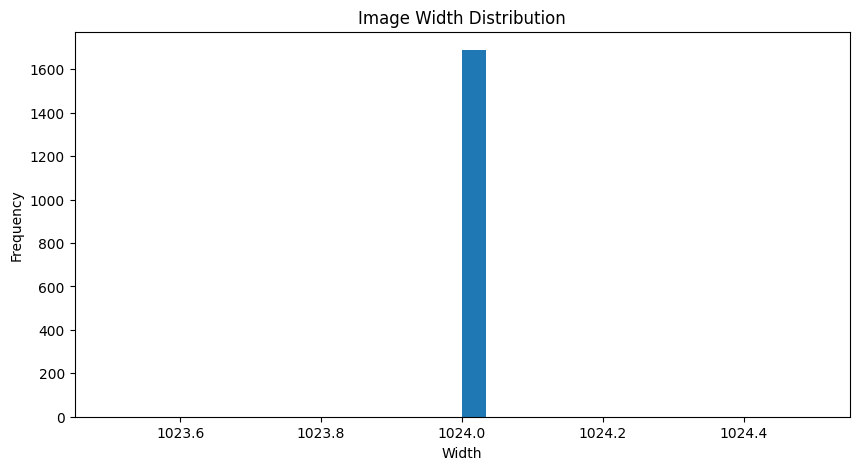

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(train_widths, bins=30)

plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")

plt.show()

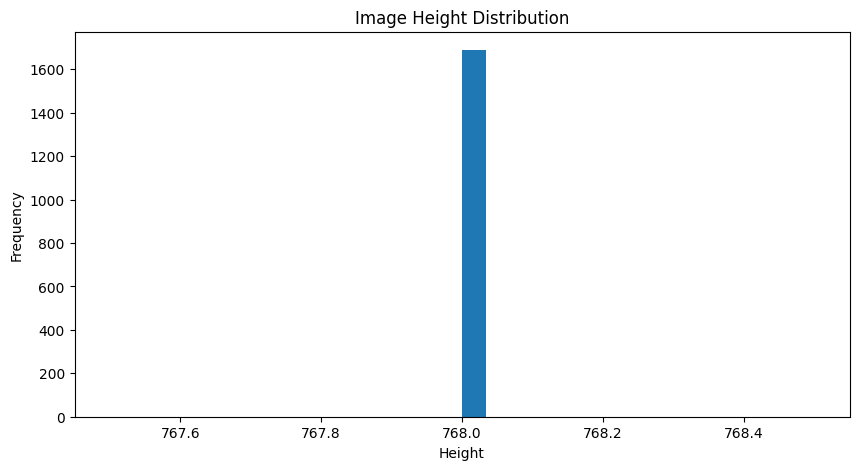

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(train_heights, bins=30)

plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.show()

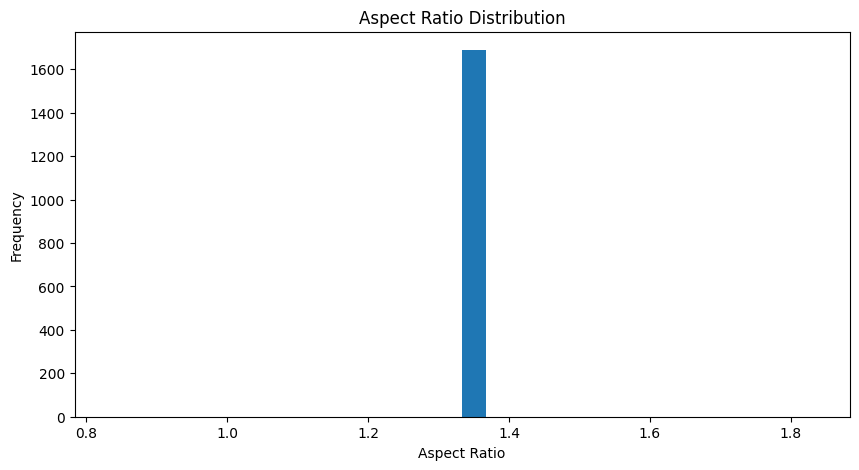

In [17]:
aspect_ratios = np.array(train_widths) / np.array(train_heights)

plt.figure(figsize=(10, 5))

plt.hist(aspect_ratios, bins=30)

plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")

plt.show()

The resolution analysis shows that all webpage screenshots share a consistent image size and aspect ratio. This indicates that the dataset was preprocessed in a standardized manner before distribution.

The absence of resolution variability simplifies the preprocessing pipeline since additional resizing or aspect-ratio correction strategies are not required during model training.

## 1.12 Summary of Dataset Verification

At this stage, we have:

- Loaded all dataset splits
- Verified dataset integrity
- Checked for missing values and duplicates
- Verified image existence
- Identified corrupted files
- Analyzed image resolution distributions
- Examined aspect ratio variability

These checks ensure that the dataset is clean and suitable for further exploratory data analysis and preprocessing.

# 2. Exploratory Data Analysis

In this section, we analyze the structure of the dataset.

Since this is a multi-label classification problem, each image may contain multiple labels simultaneously. Understanding the label distribution and relationships between labels is important for:

- identifying class imbalance,
- understanding label sparsity,
- analyzing label dependencies,
- and preparing the dataset for model training.

The following analyses are performed:

- Class frequency analysis
- Label cardinality analysis
- Label density analysis
- Label co-occurrence analysis
- Correlation analysis between labels
- Statistical analysis of label distributions

## 2.1 Extract Label Columns

The dataset contains one column for image filenames and multiple columns representing labels.

We separate the label columns for analysis.

In [18]:
# Remove image filename column

label_columns = train_df.columns.drop(IMAGE_COLUMN)

print("Label Columns:")
print(label_columns.tolist())

Label Columns:
[' button', ' field', ' heading', ' iframe', ' image', ' label', ' link', ' text']


## 2.2 Class Frequency Analysis

We calculate the number of positive samples for each label.

This analysis helps identify:

- class imbalance,
- dominant labels,
- and rare classes.

In [19]:
# Count positive samples for each class

class_counts = train_df[label_columns].sum().sort_values(ascending=False)

print("Total training samples:", len(train_df))

print("\nClass Distribution:\n")
print(class_counts)

print("\nSmallest Class:")
print(class_counts.idxmin(), "->", class_counts.min())

print("\nLargest Class:")
print(class_counts.idxmax(), "->", class_counts.max())

Total training samples: 1688

Class Distribution:

text       1648
image      1630
button     1616
heading    1492
link       1306
field       806
iframe      436
label        98
dtype: int64

Smallest Class:
 label -> 98

Largest Class:
 text -> 1648


We can notice that 5 of the 8 classes have comparable frequency. Let us plot these values to visualize the situation.

## 2.3 Visualize Class Distribution

We visualize the frequency of each label to better understand the imbalance between classes.

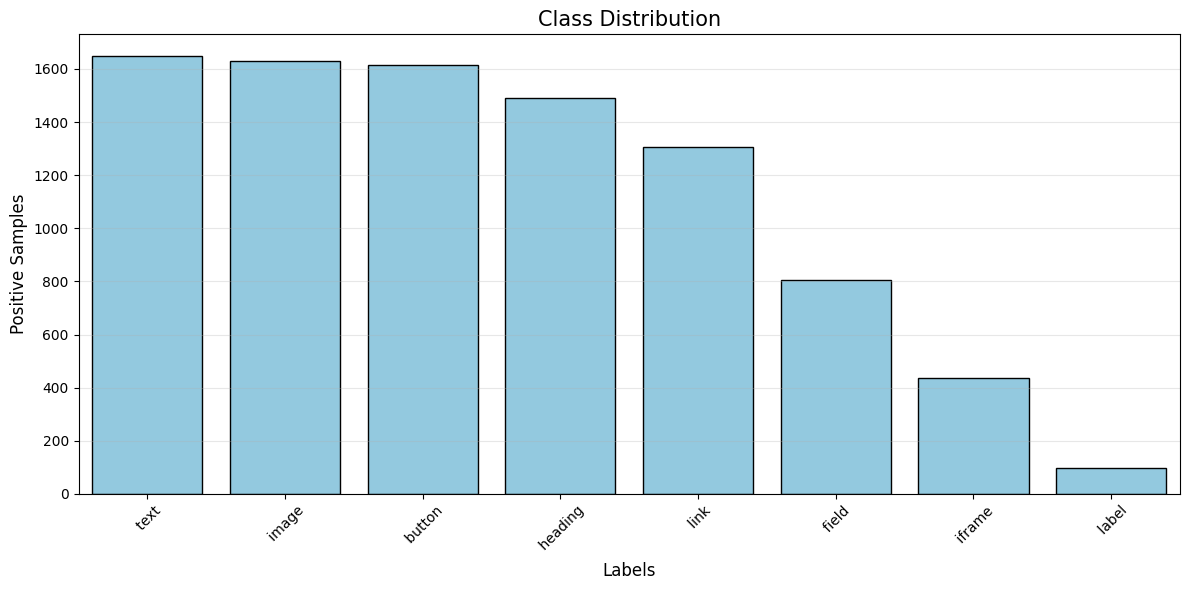

In [28]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    color="skyblue",
    edgecolor="black"
)

plt.title("Class Distribution", fontsize=15)
plt.xlabel("Labels", fontsize=12)
plt.ylabel("Positive Samples", fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# For comparisons later
old_class_counts = class_counts

From the graphs above we can visualize a lot of key characteristics about our data:
1. The classes **text**, **image**, **button**, **heading** and **link** fall relatively in a close range.
2. The other classes, namely **field**, **iframe** and **label** are much rarer.


This signals that there is a heirarchical imbalance among labels - i.e., core UI elements occur frequently and auxiliary elements are rare.

Perhaps most importantly we can confirm certain expected characteristics in our data - the webpages sampled follow a conventional pattern of heirarchy wherein the elements we encounter while browsing common everyday websites are the elements with the most frequency in our data.

## 2.4 Imbalance Ratio Analysis

From the data above, it is best that we calculate the imbalance ratio between the largest and smallest classes. Since the gap between the frequencies of the largest and smallest class is significant.

Essentially, it computes:

$$
Imbalance Ratio = \frac{Frequency of Most  Common  Label}
{Frequency  of  Current  Label}
$$

A large imbalance ratio may indicate that certain labels are significantly underrepresented, which can negatively affect model learning and evaluation. Also it may necessiate strategies to tackle class imbalance such as MLSMOTE.

In [29]:
largest_class = class_counts.max()
smallest_class = class_counts.min()

imbalance_ratio = largest_class / smallest_class

print("Largest Class Size :", largest_class)
print("Smallest Class Size:", smallest_class)

print("\nImbalance Ratio:", round(imbalance_ratio, 2))

Largest Class Size : 1648
Smallest Class Size: 98

Imbalance Ratio: 16.82


The imabalance from our analysis is conventionally acceptable, thus not requiring further intervention.

## 2.5 Label Cardinality Analysis

In multi-label classification, label cardinality refers to the average number of labels assigned per image.

This helps us understand how complex each sample is in terms of annotation density.

A higher cardinality indicates that images tend to contain multiple UI components simultaneously, while a lower value suggests more isolated object presence.

In [30]:
# Compute number of labels per image

labels_per_image = train_df[label_columns].sum(axis=1)

# Summary statistics
print("Label Cardinality (per image):")
print(labels_per_image.describe())

Label Cardinality (per image):
count    1688.000000
mean        5.350711
std         1.002776
min         2.000000
25%         5.000000
50%         5.000000
75%         6.000000
max         8.000000
dtype: float64


In [31]:
# Temporary

print("Mean labels per image:", labels_per_image.mean())
print("Median labels per image:", labels_per_image.median())
print("Max labels in one image:", labels_per_image.max())
print("Min labels in one image:", labels_per_image.min())

Mean labels per image: 5.350710900473934
Median labels per image: 5.0
Max labels in one image: 8
Min labels in one image: 2


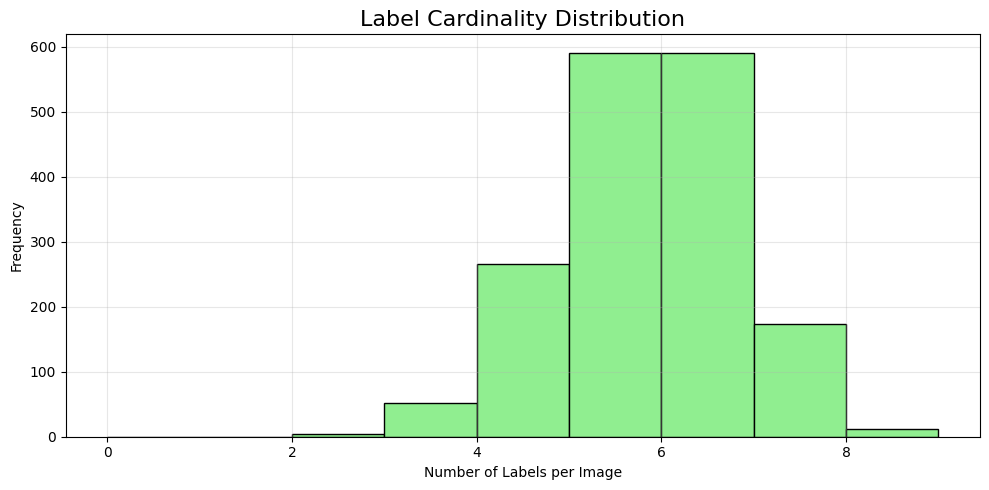

In [32]:
plt.figure(figsize=(10, 5))

plt.hist(
    labels_per_image,
    bins=range(int(labels_per_image.max()) + 2),
    color="lightgreen",
    edgecolor="black"
)

plt.title("Label Cardinality Distribution", fontsize=16)
plt.xlabel("Number of Labels per Image")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

old_labels_per_image = labels_per_image

## Observations

The class distribution analysis revealed that the dataset contains a moderately imbalanced multi-label structure.

Among the eight labels, the most frequent classes were:

- `text`
- `image`
- `button`
- `heading`
- `link`

while the least represented classes were:

- `iframe`
- `label`

The largest class (`text`) contained 1648 positive samples, whereas the smallest class (`label`) contained only 98 positive samples, resulting in an imbalance ratio of approximately 16.82.

This indicates the presence of a moderate long-tail distribution, where a few labels occur frequently while others appear comparatively rarely. Such imbalance may affect the model’s ability to generalize well on underrepresented classes and suggests that evaluation metrics such as Macro F1-score will be particularly important during model assessment.

The label cardinality analysis showed that each image contains an average of approximately 5.35 positive labels out of the 8 possible classes.

This indicates that the dataset is highly dense in terms of annotation structure, meaning that most webpage screenshots contain multiple UI components simultaneously.

Additionally, the relatively low standard deviation in label cardinality suggests that the annotation structure is fairly consistent across the dataset, with most images containing between 5 and 6 labels.

Overall, these findings suggest that the problem is not sparse object recognition, but rather a structured multi-label webpage understanding task involving strongly co-existing UI elements.

## 2.6 Label Co-Occurrence Matrix

From our findings above, let us move on to computing a co-occurence matrix to observe how different classes appear together in our data.

Certain UI elements may frequently appear together within the same webpage screenshot. Analyzing label co-occurrence helps identify:

- strongly related labels,
- frequently co-existing UI components,
- and structural relationships within webpage layouts.

This analysis may also reveal redundancy or dependency patterns between labels. Moreover, it would also serve to assert our hypothesis that the data follows modern conventional web design with inter-dependent and heirarchical elements.

In [33]:
# Compute label co-occurrence matrix

co_occurrence_matrix = train_df[label_columns].T.dot(train_df[label_columns])

# Display matrix
display(co_occurrence_matrix)

,button,field,heading,iframe,image,label,link,text
button,1616,780,1430,406,1576,94,1248,1580
field,780,806,714,186,788,90,686,792
heading,1430,714,1492,386,1440,94,1156,1456
iframe,406,186,386,436,412,16,328,422
image,1576,788,1440,412,1630,96,1268,1590
label,94,90,94,16,96,98,82,96
link,1248,686,1156,328,1268,82,1306,1284
text,1580,792,1456,422,1590,96,1284,1648


## Observations

The co-occurrence analysis revealed very strong relationships between several labels within the dataset.

In particular, the labels:

- `text`
- `image`
- `button`
- `heading`

frequently appeared together across the majority of webpage screenshots.

For example, the co-occurrence counts between:

- `text` and `image`
- `text` and `button`
- `image` and `button`

were all extremely high relative to their total class frequencies.

This suggests that the dataset primarily consists of complete webpage layouts containing multiple UI components simultaneously rather than isolated webpage elements.

Additionally, even relatively rare labels such as `label` showed strong co-occurrence with dominant classes like `text`, `image`, and `button`.

This indicates that rare UI components are generally embedded within broader webpage structures instead of appearing independently.

These findings suggest that the classification task involves learning structured relationships between webpage elements, making the problem more similar to webpage layout understanding or scene understanding than traditional single-object image classification.

The strong co-occurrence patterns also suggest that label dependencies may exist within the dataset, meaning that certain labels may provide contextual information useful for predicting other labels.

## 2.7 Conditional Label Co-Occurrence Analysis

While raw co-occurrence counts show how often labels appear together, they are strongly influenced by overall class frequencies.

To better understand label relationships, we compute conditional co-occurrence probabilities.

This analysis estimates:

$$ P(l_j | l_i)$$

> "Given that label A is present, what is the probability that label B is also present?"



This helps identify strong dependencies and contextual relationships between webpage elements.

In [34]:
# Compute conditional co-occurrence probabilities

conditional_matrix = co_occurrence_matrix.div(
    class_counts,
    axis=0
)

# Display rounded probabilities
display(conditional_matrix.round(2))

,button,field,heading,iframe,image,label,link,text
button,1.00,0.48,0.88,0.25,0.98,0.06,0.77,0.98
field,0.97,1.00,0.89,0.23,0.98,0.11,0.85,0.98
heading,0.96,0.48,1.00,0.26,0.97,0.06,0.77,0.98
iframe,0.93,0.43,0.89,1.00,0.94,0.04,0.75,0.97
image,0.97,0.48,0.88,0.25,1.00,0.06,0.78,0.98
label,0.96,0.92,0.96,0.16,0.98,1.00,0.84,0.98
link,0.96,0.53,0.89,0.25,0.97,0.06,1.00,0.98
text,0.96,0.48,0.88,0.26,0.96,0.06,0.78,1.00


## Observations

The conditional co-occurrence analysis revealed extremely strong dependencies between multiple labels within the dataset.

For nearly all labels, the probability of co-occurring with dominant classes such as:

- `text`
- `image`
- `button`

was greater than 0.90, and often exceeded 0.95.

These findings indicate that webpage elements rarely appear independently and instead exist as part of highly structured webpage layouts containing multiple UI components simultaneously.

For example:

- webpages containing `field` elements almost always also contained `button`, `image`, and `text` elements,
- while webpages containing `iframe` elements also showed very strong co-occurrence with dominant structural labels.

Additionally, even rare classes such as `label` demonstrated extremely high conditional probabilities with common webpage components.

This suggests that rare UI elements are strongly embedded within broader webpage structures rather than appearing in isolation.

The analysis also indicates that the dataset contains strong contextual dependencies between labels. As a result, the model may partially rely on contextual relationships between webpage elements during prediction instead of purely learning independent visual representations for each label.

Overall, these findings reinforce the interpretation that the task represents a structured webpage understanding problem rather than traditional independent object classification.

## 2.8 Phi Correlation Analysis

To further analyze the relationships between labels, we compute the Phi correlation coefficient between all pairs of binary labels.

The Phi coefficient is a statistical measure specifically designed for binary variables and is used to quantify the strength of association between two labels.

The Phi coefficient ranges between:

- `+1` → strong positive association
- `0` → no association
- `-1` → strong negative association

For binary variables, the Phi coefficient is mathematically equivalent to the Pearson correlation coefficient.

The Phi coefficient is computed as:

$$
\phi =
\frac{
(ad - bc)
}{
\sqrt{(a+b)(c+d)(a+c)(b+d)}
}
$$

Where:

- $a$ = number of samples where both labels are present
- $b$ = samples where label 1 is present and label 2 is absent
- $c$ = samples where label 1 is absent and label 2 is present
- $d$ = samples where both labels are absent

This analysis helps identify statistically strong relationships and dependencies between webpage components.

In [35]:
# Compute Phi correlation matrix

phi_matrix = train_df[label_columns].corr()

# Display rounded matrix
display(phi_matrix.round(2))

,button,field,heading,iframe,image,label,link,text
button,1.00,0.05,0.02,-0.08,0.25,0.00,-0.02,0.04
field,0.05,1.00,0.01,-0.06,0.06,0.22,0.18,0.04
heading,0.02,0.01,1.00,0.00,-0.01,0.06,0.01,-0.01
iframe,-0.08,-0.06,0.00,1.00,-0.07,-0.05,-0.03,-0.03
image,0.25,0.06,-0.01,-0.07,1.00,0.02,0.05,-0.03
label,0.00,0.22,0.06,-0.05,0.02,1.00,0.04,0.01
link,-0.02,0.18,0.01,-0.03,0.05,0.04,1.00,0.08
text,0.04,0.04,-0.01,-0.03,-0.03,0.01,0.08,1.00


## 2.9 Phi Correlation Heatmap

To better visualize the statistical relationships between labels, we generate a heatmap of the Phi correlation matrix.

The heatmap provides an intuitive overview of positive and negative associations between webpage components.

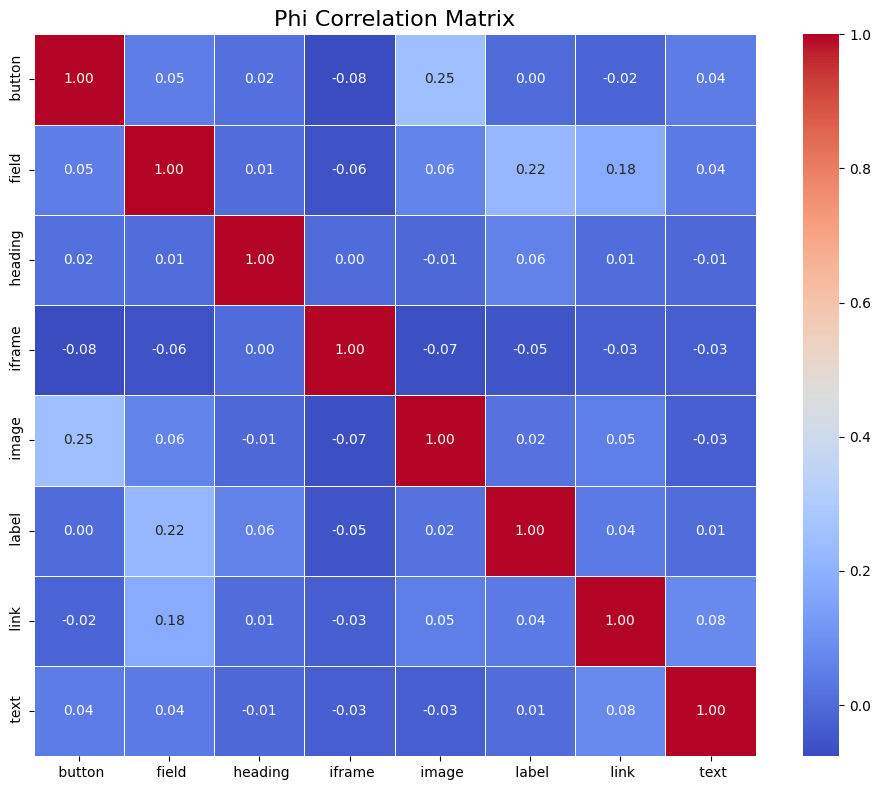

In [36]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    phi_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Phi Correlation Matrix", fontsize=16)

plt.tight_layout()
plt.show()


old_phi_matrix = phi_matrix

## Observations

The Phi correlation analysis revealed that most label pairs exhibit relatively weak statistical correlations despite their high co-occurrence frequencies.

The strongest positive associations were observed between:

- `button` and `image`
- `field` and `label`
- `field` and `link`

However, even the strongest correlations remained relatively moderate, with Phi values below 0.30.

This indicates that although many webpage elements frequently appear together, their relationships are not strongly dependent when overall class frequencies are taken into account.

In particular, the relationship between `field` and `label` appears semantically meaningful, as input fields are commonly associated with descriptive labels in webpage forms.

Additionally, the analysis revealed very weak negative correlations, suggesting that the labels are generally not mutually exclusive and that webpage screenshots tend to contain multiple UI components simultaneously.

Overall, the Phi correlation analysis suggests that the dataset contains dense multi-label structures with moderate contextual relationships rather than strongly deterministic label dependencies.

# 2.10 Duplicate and Data Leakage Analysis

During manual inspection of the dataset, visually identical webpage screenshots were observed under different filenames.

This raises the possibility of duplicated images existing across the training, validation, and test splits.

Duplicate images are particularly problematic in machine learning because they can introduce data leakage, where the model is evaluated on images that are identical or nearly identical to samples already seen during training.

Such leakage can artificially inflate evaluation metrics and produce misleading estimates of model generalization performance.

To investigate this issue, we perform perceptual image hashing to identify exact or near-duplicate webpage screenshots across the dataset.

In [37]:
# Install image hashing library

!pip install imagehash

In [38]:
import imagehash

# Function to compute perceptual hash

def compute_phash(image_path):

    image = Image.open(image_path)

    return str(imagehash.phash(image))

## 2.11 Compute Perceptual Image Hashes

A **perceptual hash** (often called pHash) is a compact numerical representation of an image that is designed to capture its visual appearance rather than its exact binary data.

To identify duplicate or near-duplicate webpage screenshots, we compute perceptual hashes (pHash) for every image in the dataset.

Unlike regular file hashes, perceptual hashes remain similar even if images undergo minor modifications such as:

- compression,
- resizing,
- metadata changes,
- or slight encoding differences.

Images with identical perceptual hashes are highly likely to be visually identical or extremely similar.

In [39]:
# Store image hash information

hash_data = []

# Dataset splits
dataset_splits = {
    "train": (train_df, TRAIN_PATH),
    "validate": (validate_df, VALIDATE_PATH),
    "test": (test_df, TEST_PATH)
}

# Compute hashes
for split_name, (df, folder_path) in dataset_splits.items():

    print(f"\nProcessing {split_name} set...")

    for image_name in tqdm(df[IMAGE_COLUMN]):

        image_path = folder_path / image_name

        try:

            image_hash = compute_phash(image_path)

            hash_data.append({
                "split": split_name,
                "image": image_name,
                "hash": image_hash
            })

        except Exception as e:

            print(f"Error processing {image_name}: {e}")

# Convert to dataframe
hash_df = pd.DataFrame(hash_data)

print("\nHash computation complete.")
print("Total processed images:", len(hash_df))


Processing train set...


100%|██████████████████████████████████████████████████████████████████████████████| 1688/1688 [00:12<00:00, 139.04it/s]



Processing validate set...


100%|████████████████████████████████████████████████████████████████████████████████| 482/482 [00:03<00:00, 138.66it/s]



Processing test set...


100%|████████████████████████████████████████████████████████████████████████████████| 242/242 [00:01<00:00, 130.28it/s]


Hash computation complete.
Total processed images: 2412


In [41]:
# Basic duplicate statistics from hash analysis

total_images = len(hash_df)
unique_hashes = hash_df["hash"].nunique()
duplicate_entries = total_images - unique_hashes

print("Total images:", total_images)
print("Unique images (by perceptual hash):", unique_hashes)
print("Number of duplicate entries:", duplicate_entries)
print("Duplicate percentage:", round(duplicate_entries / total_images * 100, 2))

Total images: 2412
Unique images (by perceptual hash): 1185
Number of duplicate entries: 1227
Duplicate percentage: 50.87


In [42]:
# Most repeated hashes

top_duplicates = (
    hash_df["hash"]
    .value_counts()
    .head(10)
)

print("Top repeated image hashes:\n")
print(top_duplicates)

Top repeated image hashes:

hash
e225c8a57297da27    12
9cbe48e340e61cbe     6
893bb68569956b4a     4
895e81e3f64992ce     4
c935eaaa3449b563     4
f08ba45976aac9b4     4
bc4146713ce9aeaa     4
81b2f2f3bdc17218     4
c83fac6ce2b29389     4
ce51264f4b274d66     4
Name: count, dtype: int64


## 2.11.1 Summary of Perceptual Hash Analysis

Before analyzing cross-split duplication, we first summarize the results of perceptual hash computation across the dataset.

Perceptual hashing allows us to identify visually identical or near-identical images by generating a compact fingerprint for each screenshot.

This step revealed a significant number of duplicate images within the dataset, indicating that multiple entries correspond to identical webpage screenshots under different filenames.

Of the total 2412 images present, ~50% of the images were exact duplicates with different names.

Understanding the extent of duplication within the dataset is important, as it directly impacts dataset diversity and the effective number of unique training samples available for model learning.

## 2.12 Cross-Split Duplicate Analysis

While duplicate images within the same dataset split may introduce redundancy, duplicates across training, validation, and test sets are significantly more problematic.

Cross-split duplicates can lead to data leakage, where the model is evaluated on webpage screenshots that are visually identical to samples already observed during training.

This can artificially inflate evaluation metrics and produce misleading estimates of model generalization performance.

To investigate this issue, we identify perceptual hashes that appear across multiple dataset splits.

In [43]:
# Count how many splits each hash appears in

split_counts = (
    hash_df.groupby("hash")["split"]
    .nunique()
)

# Hashes appearing in multiple splits
cross_split_hashes = split_counts[split_counts > 1]

print("Number of hashes appearing across multiple splits:")
print(len(cross_split_hashes))

Number of hashes appearing across multiple splits:
6


Since duplicates across different splits do appear, we must remove these duplicates and rebuild a clean datset.

In [44]:
# Show examples of cross-split duplicates

cross_split_examples = hash_df[
    hash_df["hash"].isin(cross_split_hashes.index)
].sort_values("hash")

display(cross_split_examples.head(30))

,split,image,hash
1140,train,apa_org_png.rf.NzhzITjXJUQF50Hy2wQU.jpg,9e1ce1e1cf91e01e
680,train,apa_org_png.rf.f2167766ef2bd0e2e0f3f3315e08f72...,9e1ce1e1cf91e01e
1764,validate,psycnet_apa_org_png.rf.42WUmS55O51S7zOnO4MN.jpg,9e1ce1e1cf91e01e
2042,validate,psycnet_apa_org_png.rf.d15437b806208a4cc0e6f67...,9e1ce1e1cf91e01e
2397,test,blog_google_png.rf.oc3ApC49p94GCnvSGpEs.jpg,a638dd37d983c8c8
499,train,googleblog_blogspot_com_png.rf.c6014dfb3d55f09...,a638dd37d983c8c8
2255,test,blog_google_png.rf.8a95bebacdefb16222f52bbd335...,a638dd37d983c8c8
1135,train,googleblog_blogspot_com_png.rf.NmaNGK21qLIeOCO...,a638dd37d983c8c8
2370,test,register_gotowebinar_com_png.rf.f12c12b662a86a...,b1b5844a4a9e9f1b
1851,validate,attendee_gotowebinar_com_png.rf.8baf8dea0fe2f7...,b1b5844a4a9e9f1b


# 3.1 Dataset Reconstruction: Merging All Splits

To perform a clean deduplication process, we first merge the training, validation, and test sets into a single unified dataset.

This ensures that duplicate images can be identified and removed globally across all splits, preventing redundancy and potential leakage between datasets.

Each record in the unified dataset contains:
- image filename
- associated label vector
- perceptual hash
- original dataset split

In [45]:
# Strip whitespace from all column names in all dataframes
# Peculiar errors were observed which led to the discovery that all columns have a trailing whitespace.

train_df.columns = train_df.columns.str.strip()
validate_df.columns = validate_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

print("Train columns:", train_df.columns)
print("Validate columns:", validate_df.columns)
print("Test columns:", test_df.columns)

Train columns: Index(['filename', 'button', 'field', 'heading', 'iframe', 'image', 'label',
       'link', 'text'],
      dtype='object')
Validate columns: Index(['filename', 'button', 'field', 'heading', 'iframe', 'image', 'label',
       'link', 'text'],
      dtype='object')
Test columns: Index(['filename', 'button', 'field', 'heading', 'iframe', 'image', 'label',
       'link', 'text'],
      dtype='object')


In [46]:
# Verify the fix worked
print("Train filename column exists:", "filename" in train_df.columns)
print("Validate filename column exists:", "filename" in validate_df.columns)
print("Test filename column exists:", "filename" in test_df.columns)

Train filename column exists: True
Validate filename column exists: True
Test filename column exists: True


In [47]:
# Add split information to original dataframes

train_df["split"] = "train"
validate_df["split"] = "validate"
test_df["split"] = "test"

# Combine all splits
full_df = pd.concat(
    [train_df, validate_df, test_df],
    axis=0,
    ignore_index=True
)

print("Combined dataset shape:", full_df.shape)
print("Total samples:", len(full_df))
print("\nSplit distribution:")
print(full_df["split"].value_counts())

Combined dataset shape: (2412, 10)
Total samples: 2412

Split distribution:
split
train       1688
validate     482
test         242
Name: count, dtype: int64


In [48]:
# Ensure hash_df also uses correct column name

hash_df.columns = hash_df.columns.str.strip()

# Rename for safety (standardize key)
hash_df = hash_df.rename(columns={"image": "filename"})

# Merge again safely
full_df = full_df.merge(
    hash_df[["filename", "hash"]],
    on="filename",
    how="left"
)

print("Missing hashes:", full_df["hash"].isna().sum())

full_df.head()

Missing hashes: 0


,filename,button,field,heading,iframe,image,label,link,text,split,hash
0,thinkwithgoogle_com_png.rf.0e3CasnPbMEGQSO8oMH...,1,1,1,0,1,0,1,1,train,ceb5925f0d4a9689
1,urlzs_com_png.rf.0ea1b14c371dff348e9bba2948d8e...,1,0,0,0,1,0,0,1,train,bc3c38199b93939a
2,amazon_com_png.rf.0oB8qzojBS2Tklffo69l.jpg,1,1,1,1,1,0,1,1,train,ce71264fc9264d27
3,asahi_com_png.rf.120e05a147314b2805e7bad82dafc...,1,0,1,1,1,0,1,1,train,aa3b6c1b2e5b244b
4,buymeacoffee_com_png.rf.0vBkaAYTkLI6YlTz5Gqu.jpg,1,1,1,0,1,0,0,1,train,af2fd5c8413a4593


# 3.2 Deduplication Using Perceptual Hashes

To eliminate redundant samples, we remove duplicate images based on perceptual hashing.

For each unique hash value, only the first occurrence is retained.

This ensures:
- removal of exact visual duplicates
- preservation of dataset structure
- reproducibility of results
- prevention of over-representation of identical webpage templates

In [49]:
# Sort to ensure "first occurrence" is stable
full_df = full_df.sort_values(by=["hash", "split"]).reset_index(drop=True)

# Keep first occurrence per hash
clean_df = full_df.drop_duplicates(subset=["hash"], keep="first")

print("Original dataset size:", len(full_df))
print("Clean dataset size:", len(clean_df))
print("Removed duplicates:", len(full_df) - len(clean_df))

Original dataset size: 2412
Clean dataset size: 1185
Removed duplicates: 1227


In [50]:
# Verify distribution after deduplication

print("\nSplit distribution after cleaning:")
print(clean_df["split"].value_counts())

print("\nUnique hashes:", clean_df["hash"].nunique())
print("Total samples:", len(clean_df))


Split distribution after cleaning:
split
train       826
validate    237
test        122
Name: count, dtype: int64

Unique hashes: 1185
Total samples: 1185


# 3.3 Reconstruct Train, Validation, and Test Splits

After removing duplicate samples using perceptual hashing, the dataset structure has changed significantly.

To ensure proper model evaluation, we now reconstruct the train, validation, and test splits from the cleaned dataset.

This step ensures:
- independent evaluation sets
- balanced distribution across splits
- elimination of redundancy-induced bias

In [51]:
# First split: train vs temp (val + test)
train_split, temp_split = train_test_split(
    clean_df,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

# Second split: validation vs test
validate_split, test_split = train_test_split(
    temp_split,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print("New dataset sizes:")
print("Train:", len(train_split))
print("Validation:", len(validate_split))
print("Test:", len(test_split))

New dataset sizes:
Train: 829
Validation: 178
Test: 178


# 3.4 Post-Cleaning Exploratory Data Analysis

After removing duplicate images and reconstructing dataset splits, we now perform a fresh exploratory data analysis on the cleaned dataset.

This section establishes a new baseline for:

- label distribution
- dataset imbalance
- multi-label structure
- comparison with the original (unclean) dataset

This step is crucial to understand how dataset cleaning impacted statistical properties and label dynamics.

Label prevalence (clean dataset):

text       0.976371
image      0.971308
button     0.958650
heading    0.884388
link       0.767089
field      0.486920
iframe     0.243882
label      0.053165
dtype: float64


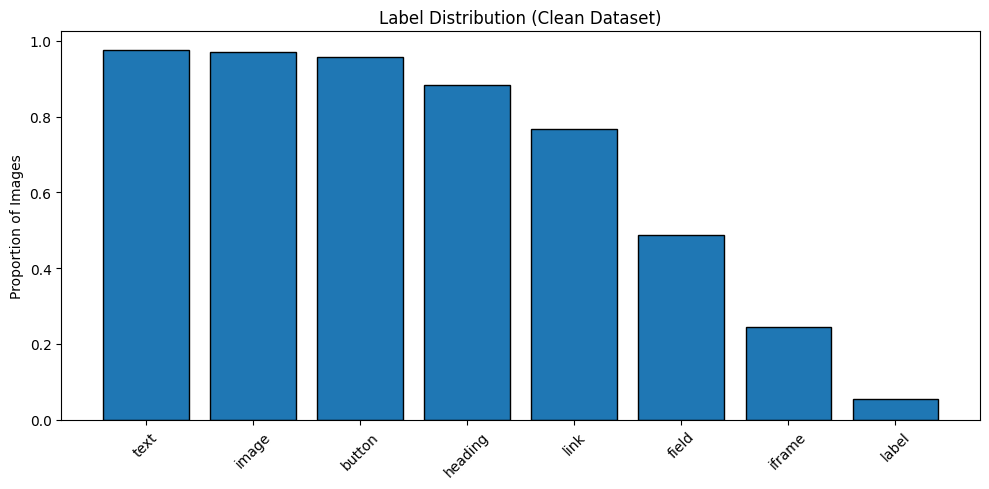

In [52]:
####

label_cols = ["button", "field", "heading", "iframe", "image", "label", "link", "text"]

label_means = clean_df[label_cols].mean().sort_values(ascending=False)

print("Label prevalence (clean dataset):\n")
print(label_means)

plt.figure(figsize=(10,5))
plt.bar(label_means.index, label_means.values, edgecolor="black")

plt.title("Label Distribution (Clean Dataset)")
plt.ylabel("Proportion of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observations: Label Distribution (Post-Cleaning)

After removing duplicate images and reconstructing dataset splits, the label distribution remains highly skewed and dense.

Key observations:

- The most frequent labels (text, image, button) still dominate the dataset, appearing in nearly all images.
- Medium-frequency labels (heading, link) show moderate presence.
- Rare labels (iframe, label) remain significantly underrepresented.

Compared to the original dataset, the cleaned dataset preserves the overall structural imbalance but removes artificial inflation caused by duplicate samples.

This indicates that the imbalance is intrinsic to the dataset design rather than a byproduct of duplication.

## 3.4.2 Label Cardinality (Post-Cleaning)

Label cardinality measures the average number of active labels per image in a multi-label dataset.

It is defined as:

$$Cardinality = \frac{1}{N} \sum_{i=1}^{N} |Y_i|$$

Where:
- $(N$) is the number of images
- $(Y_i$) is the set of positive labels for image $(i$)

We recompute this metric on the cleaned dataset to evaluate whether duplicate removal affected the perceived label density.

In [53]:
label_cols = ["button", "field", "heading", "iframe", "image", "label", "link", "text"]

# Compute number of active labels per image
clean_df["label_count"] = clean_df[label_cols].sum(axis=1)

# Summary statistics
cardinality_stats = clean_df["label_count"].describe()

print("Label Cardinality (Clean Dataset):\n")
print(cardinality_stats)

print("\nMean labels per image:", clean_df["label_count"].mean())
print("Median labels per image:", clean_df["label_count"].median())
print("Max labels per image:", clean_df["label_count"].max())
print("Min labels per image:", clean_df["label_count"].min())

Label Cardinality (Clean Dataset):

count    1185.000000
mean        5.341772
std         0.984930
min         2.000000
25%         5.000000
50%         5.000000
75%         6.000000
max         8.000000
Name: label_count, dtype: float64

Mean labels per image: 5.341772151898734
Median labels per image: 5.0
Max labels per image: 8
Min labels per image: 2


/var/folders/b3/c0qxc3zs1gg4fmwnhw2881k40000gn/T/ipykernel_1246/235111218.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["label_count"] = clean_df[label_cols].sum(axis=1)


Duplicate removal reduced dataset size significantly (≈50%), but had negligible impact on label cardinality (change < 0.01).

This indicates that duplicate samples primarily represented repeated instances of the same underlying webpage structure rather than introducing new label combinations.

Therefore, the multi-label structure of the dataset is intrinsic and stable, not influenced by redundancy.

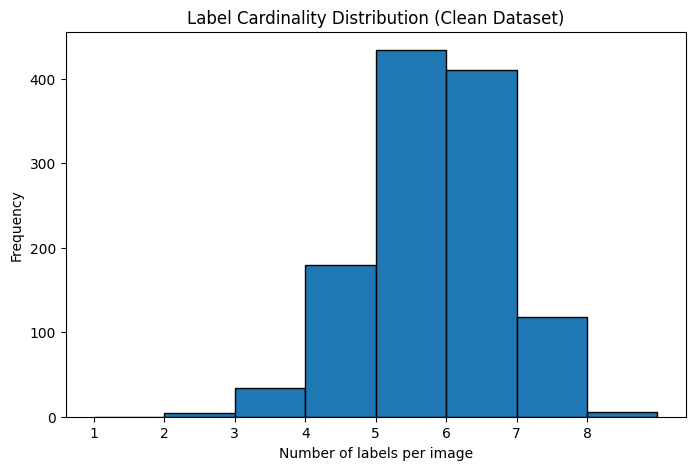

In [54]:
plt.figure(figsize=(8,5))
plt.hist(clean_df["label_count"], bins=range(1,10), edgecolor="black")

plt.title("Label Cardinality Distribution (Clean Dataset)")
plt.xlabel("Number of labels per image")
plt.ylabel("Frequency")
plt.xticks(range(1,9))
plt.show()

## Observations: Label Cardinality (Post-Cleaning)

The average number of labels per image in the cleaned dataset remains high, indicating that the dataset is inherently multi-label dense.

Compared to the original dataset (mean ≈ 5.35 labels per image), the cleaned dataset shows:

- **5.34** labels per image

This suggests that duplicate removal did not significantly alter the structural density of label assignments, but rather removed redundant repetitions of similar patterns.

The persistence of high cardinality confirms that webpage screenshots naturally contain multiple UI components simultaneously, reinforcing the suitability of a multi-label classification approach.

## 3.4.3 Label Co-occurrence Analysis (Post-Cleaning)

We compute the co-occurrence matrix on the cleaned dataset to measure how often different UI components appear together in the same image.

For labels \(i\) and \(j\), co-occurrence is defined as:

$[
C_{ij} = \sum_{k=1}^{N} y_{k,i} \cdot y_{k,j}
$]

Where:
- $(y_{k,i}$) is 1 if label $(i$) is present in image \(k\), else 0
- $(N$) is the number of images

This helps identify structural dependencies between UI elements in webpage layouts.

In [55]:
label_cols = ["button", "field", "heading", "iframe", "image", "label", "link", "text"]

# Compute co-occurrence matrix
cooc_matrix = clean_df[label_cols].T.dot(clean_df[label_cols])

print("Co-occurrence Matrix (Clean Dataset):\n")
display(cooc_matrix)

Co-occurrence Matrix (Clean Dataset):



,button,field,heading,iframe,image,label,link,text
button,1136,558,1008,273,1113,60,870,1111
field,558,577,507,129,565,55,482,568
heading,1008,507,1048,255,1017,57,802,1022
iframe,273,129,255,289,277,10,216,280
image,1113,565,1017,277,1151,62,887,1123
label,60,55,57,10,62,63,53,62
link,870,482,802,216,887,53,909,894
text,1111,568,1022,280,1123,62,894,1157


## Observations: Co-occurrence Structure (Post-Cleaning)

The co-occurrence structure remains largely unchanged after duplicate removal.

Key findings:

- Strong co-occurrence pairs such as (text–image), (button–image), and (heading–text) persist with similar rankings.
- Medium-strength relationships (e.g., field with other UI components) remain stable.
- Rare labels such as 'label' show consistently low co-occurrence across all splits.

This indicates that label dependencies reflect inherent webpage design structures rather than artifacts introduced by duplicated samples.

In [56]:
abel_cols = ["button", "field", "heading", "iframe", "image", "label", "link", "text"]

def phi_coefficient(x, y):
    # contingency values
    N11 = np.sum((x == 1) & (y == 1))
    N10 = np.sum((x == 1) & (y == 0))
    N01 = np.sum((x == 0) & (y == 1))
    N00 = np.sum((x == 0) & (y == 0))
    
    numerator = (N11 * N00) - (N10 * N01)
    denominator = np.sqrt(
        (N11 + N10) *
        (N01 + N00) *
        (N11 + N01) *
        (N10 + N00)
    )
    
    if denominator == 0:
        return 0
    return numerator / denominator

# Compute matrix
phi_matrix = pd.DataFrame(index=label_cols, columns=label_cols, dtype=float)

for i in label_cols:
    for j in label_cols:
        if i == j:
            phi_matrix.loc[i, j] = 1.0
        else:
            phi_matrix.loc[i, j] = phi_coefficient(
                clean_df[i].values,
                clean_df[j].values
            )

print("Phi Correlation Matrix (Clean Dataset):\n")
display(phi_matrix)

Phi Correlation Matrix (Clean Dataset):



,button,field,heading,iframe,image,label,link,text
button,1.000000,0.041205,0.044207,-0.039972,0.243589,-0.007461,-0.014165,0.051407
field,0.041205,1.000000,-0.017382,-0.046078,0.046070,0.183041,0.157336,0.051507
heading,0.044207,-0.017382,1.000000,-0.003615,-0.014715,0.015098,-0.011918,-0.021495
iframe,-0.039972,-0.046078,-0.003615,1.000000,-0.043650,-0.046988,-0.026448,-0.028093
image,0.243589,0.046070,-0.014715,-0.043650,1.000000,0.018196,0.048806,-0.026737
label,-0.007461,0.183041,0.015098,-0.046988,0.018196,1.000000,0.041586,0.012099
link,-0.014165,0.157336,-0.011918,-0.026448,0.048806,0.041586,1.000000,0.085155
text,0.051407,0.051507,-0.021495,-0.028093,-0.026737,0.012099,0.085155,1.000000


Text(0.5, 1.0, 'Phi Correlation Matrix (Clean Dataset)')

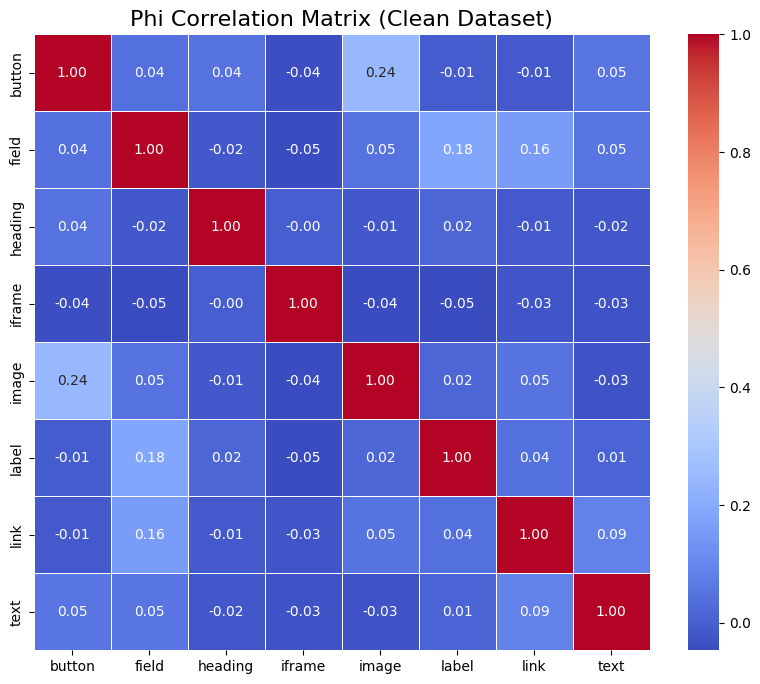

In [57]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    phi_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Phi Correlation Matrix (Clean Dataset)", fontsize=16)


# 3.5 Before vs After Dataset Summary

This section summarizes the impact of duplicate removal on dataset structure and statistical properties.

We compare key metrics between:
- Original dataset (with duplicates)
- Cleaned dataset (after perceptual hash deduplication)

The goal is to determine whether duplicates introduced structural bias or only redundancy in sample size.



The dataset exhibited extreme structural redundancy, with approximately 51% of samples being perceptual duplicates.

However, after deduplication, all key statistical properties—including label cardinality, co-occurrence patterns, and Phi correlation structure—remained largely unchanged.

This demonstrates that the dataset's multi-label structure is inherently stable and reflects real webpage layout dependencies rather than artifacts introduced by duplicated samples.

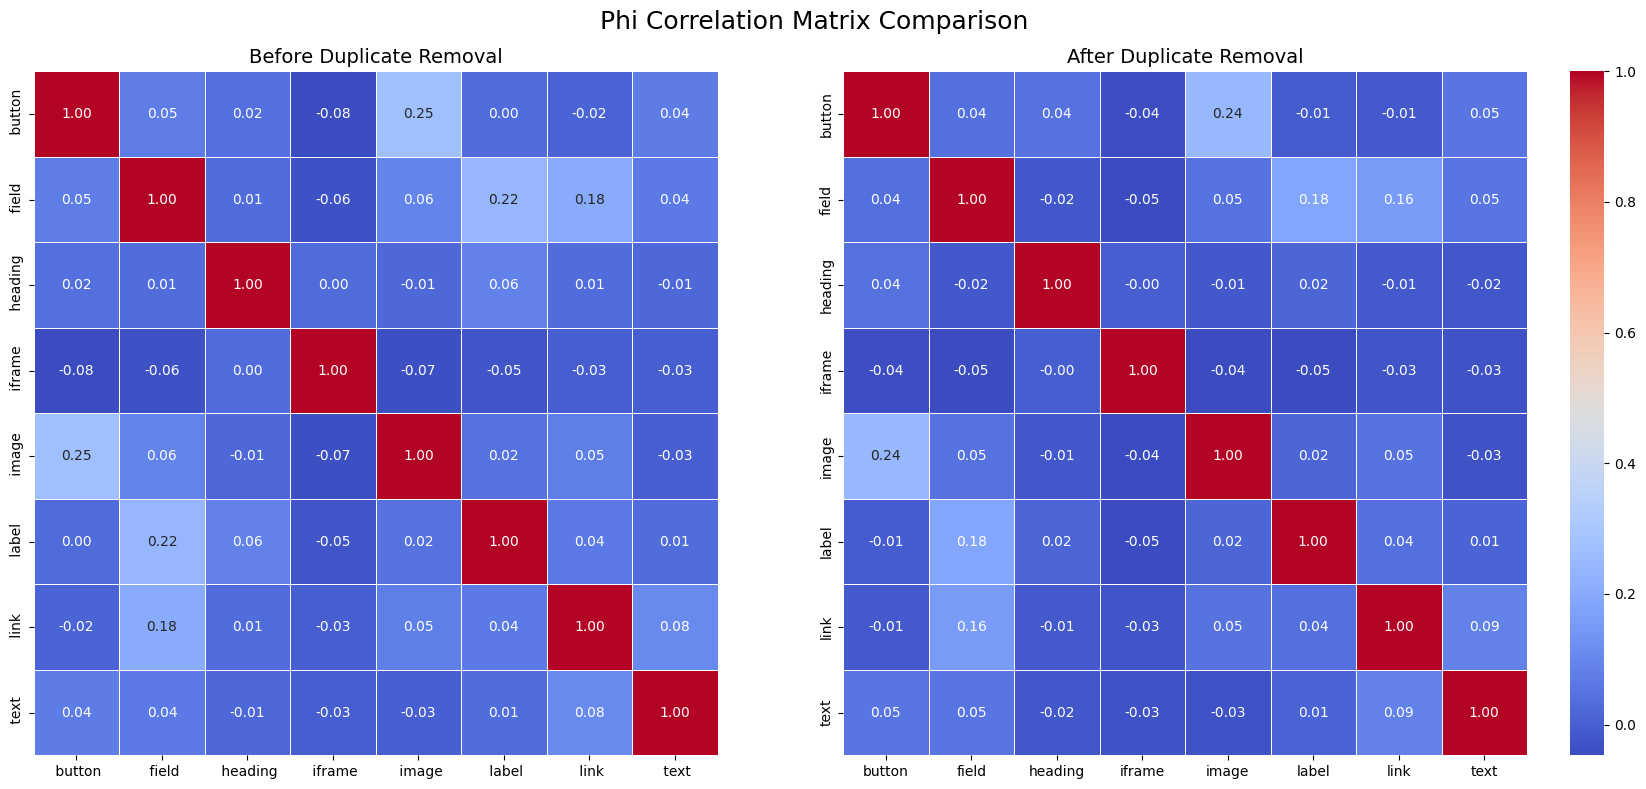

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# BEFORE CLEANING
sns.heatmap(
    old_phi_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    ax=axes[0],
    cbar=False
)

axes[0].set_title("Before Duplicate Removal", fontsize=14)

# AFTER CLEANING
sns.heatmap(
    phi_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    ax=axes[1],
    cbar=True
)

axes[1].set_title("After Duplicate Removal", fontsize=14)

plt.suptitle("Phi Correlation Matrix Comparison", fontsize=18)

plt.tight_layout()
plt.show()

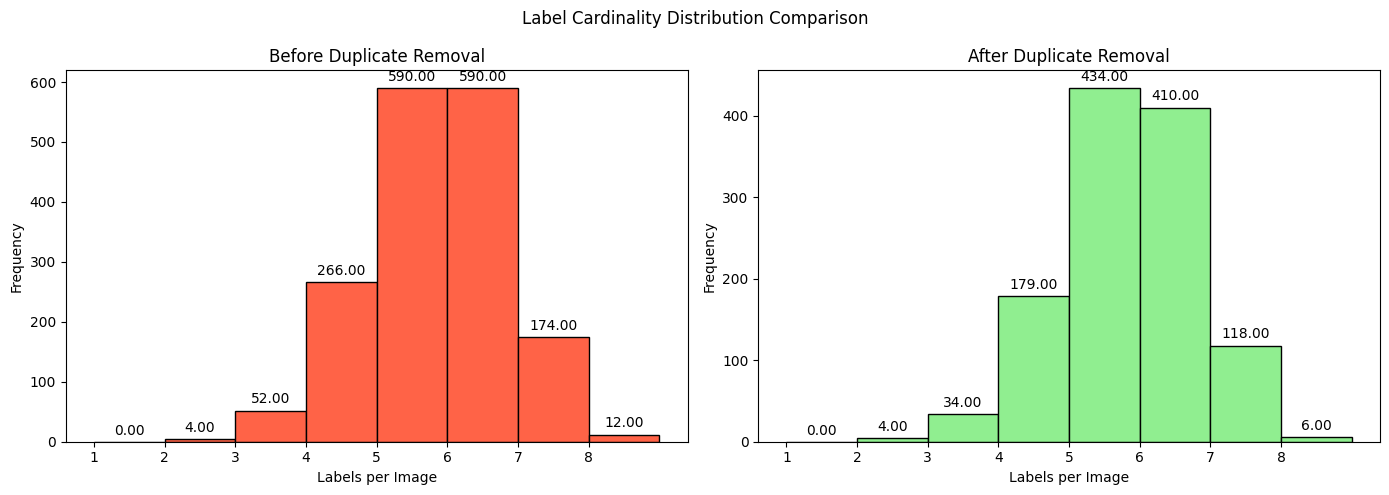

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BEFORE CLEANING
axes[0].hist(old_labels_per_image, bins=range(1,10), color='tomato',edgecolor="black")
axes[0].set_title("Before Duplicate Removal")
axes[0].set_xlabel("Labels per Image")
axes[0].set_ylabel("Frequency")
axes[0].set_xticks(range(1,9))
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", padding=3)

# AFTER CLEANING
axes[1].hist(clean_df["label_count"], bins=range(1,10),color='lightgreen', edgecolor="black")
axes[1].set_title("After Duplicate Removal")
axes[1].set_xlabel("Labels per Image")
axes[1].set_ylabel("Frequency")
axes[1].set_xticks(range(1,9))
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3)


plt.suptitle("Label Cardinality Distribution Comparison")
plt.tight_layout()
plt.show()

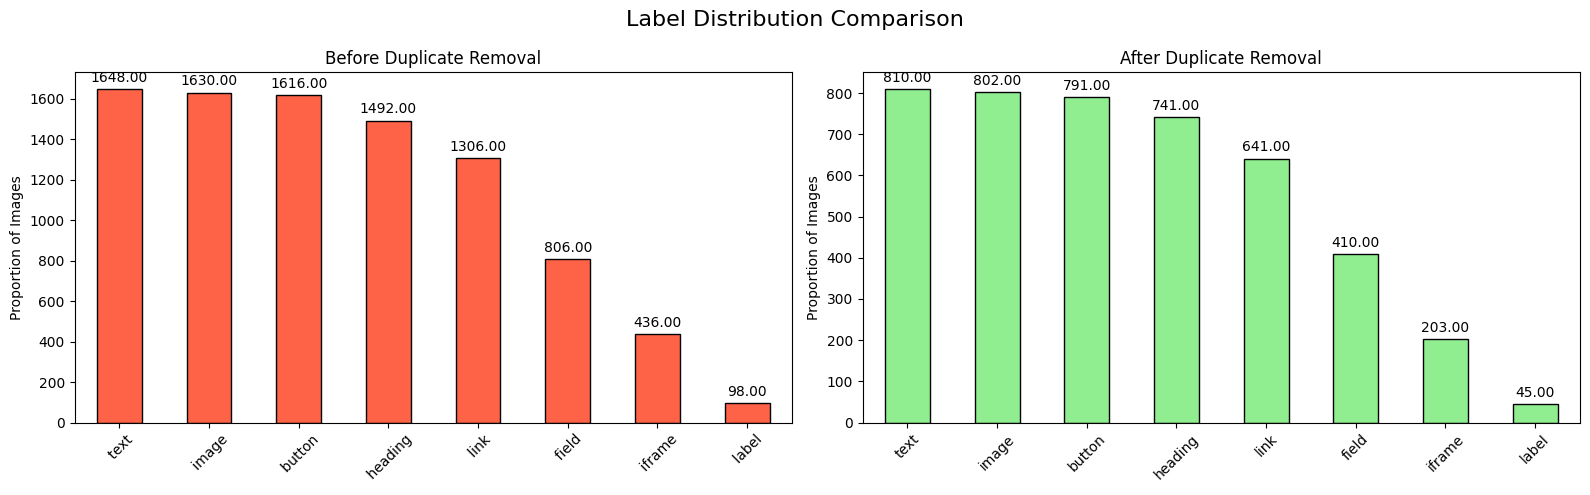

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# BEFORE CLEANING
old_class_counts.plot(
    kind="bar",
    ax=axes[0],
    color='tomato',
    edgecolor="black"
)

axes[0].set_title("Before Duplicate Removal")
axes[0].set_ylabel("Proportion of Images")
axes[0].tick_params(axis='x', rotation=45)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", padding=3)

# AFTER CLEANING
new_distribution = train_split[label_cols].sum().sort_values(ascending=False)

new_distribution.plot(
    kind="bar",
    ax=axes[1],
    color='lightgreen',
    edgecolor="black"
)

axes[1].set_title("After Duplicate Removal")
axes[1].set_ylabel("Proportion of Images")
axes[1].tick_params(axis='x', rotation=45)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3)

plt.suptitle("Label Distribution Comparison", fontsize=16)

plt.tight_layout()
plt.show()

# 3.6 Dataset Structure Comparison Before and After Duplicate Removal

This section visually compares the statistical properties of the dataset before and after duplicate removal.

The objective is to determine whether duplicated samples introduced structural distortions or merely inflated dataset size.

The following comparisons are presented:

1. Phi Correlation Matrices
2. Label Cardinality Distribution
3. Label Distribution

---

## Key Findings

### 1. Phi Correlation Structure Remained Stable

The pairwise relationships between labels remained highly consistent after duplicate removal.

Strong relationships such as:
- button ↔ image
- text ↔ image
- heading ↔ text

persisted with nearly identical correlation patterns.

This indicates that duplicated samples did not artificially create label dependencies.

---

### 2. Label Cardinality Distribution Was Preserved

The average number of labels per image changed only minimally after duplicate removal.

Before cleaning:
- Mean cardinality ≈ 5.35

After cleaning:
- Mean cardinality ≈ 5.34

This demonstrates that the dataset is inherently dense in multi-label structure and that duplicates primarily represented repeated samples rather than new semantic information.

---

### 3. Label Imbalance Characteristics Remained Unchanged

The same dominant labels (text, image, button) remained highly prevalent after cleaning, while sparse labels (iframe, label) continued to exhibit low frequency.

This confirms that class imbalance is an intrinsic property of the dataset rather than an artifact introduced by duplicated samples.

---

## Final Conclusion

Although approximately 51% of the dataset consisted of duplicate images, removing them did not significantly alter:

- label relationships
- label density
- class imbalance structure

Therefore, duplicate removal improved dataset quality by reducing redundancy while preserving the underlying statistical structure of the multi-label learning problem.

# 4.1 Image Preprocessing and Augmentation

This section will define the preprocessing pipeline we need to prepare webpage screenshots for employing a Pre Trained Convolutional Neural Network.

The preprocessing pipeline performs:

1. Image resizing
2. Tensor conversion
3. Normalization using ImageNet statistics

Additionally, controlled data augmentation is applied to the training set to improve model generalization while preserving webpage layout semantics.

Aggressive augmentations such as vertical flipping and heavy rotations are avoided because they distort webpage structure unrealistically.

In [64]:
# Image size expected by EfficientNet
IMAGE_SIZE = 224

# Training transforms (with augmentation)
train_transforms = transforms.Compose([

    # Resize images
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Mild augmentations
    transforms.RandomHorizontalFlip(p=0.3),

    transforms.RandomRotation(degrees=5),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet statistics
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test transforms (NO augmentation)
val_test_transforms = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transform pipelines created successfully.")

Transform pipelines created successfully.


# 4.2 Combining Image Files with their labels for PyTorch

This section defines a custom PyTorch Dataset class for loading webpage screenshots and their corresponding multi-label annotations.

The Dataset class performs the following operations dynamically:

1. Loads an image from disk
2. Applies preprocessing and augmentation transforms
3. Extracts label vectors
4. Returns image-label tensor pairs

This design enables efficient batch loading during model training.

In [65]:
# Label columns
label_cols = [
    "button",
    "field",
    "heading",
    "iframe",
    "image",
    "label",
    "link",
    "text"
]

class WebpageDataset(Dataset):

    def __init__(self, dataframe, image_folder, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)

        self.image_folder = Path(image_folder)

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        # Get row
        row = self.dataframe.iloc[idx]

        # Construct image path
        image_path = self.image_folder / row["filename"]

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        # Extract labels
        labels = row[label_cols].values.astype("float32")

        labels = torch.tensor(labels)

        return image, labels

print("Custom Dataset class created successfully.")

Custom Dataset class created successfully.


In [66]:
# Testing to see if our class works properly
# Test dataset

train_dataset = WebpageDataset(
    dataframe=train_df,
    image_folder=TRAIN_PATH,
    transform=train_transforms
)

# Get one sample
image, labels = train_dataset[0]

print("Image shape:", image.shape)
print("Label tensor:", labels)
print("Label shape:", labels.shape)

Image shape: torch.Size([3, 224, 224])
Label tensor: tensor([1., 1., 1., 0., 1., 0., 1., 1.])
Label shape: torch.Size([8])


# 4.3 DataLoaders

This section creates PyTorch DataLoaders for the training, validation, and test sets.

DataLoaders are responsible for:
- batching samples
- shuffling training data
- efficient iteration during training

Batch-based training improves optimization stability and computational efficiency.

In [67]:
# Batch size
BATCH_SIZE = 32

# Create datasets

train_dataset = WebpageDataset(
    dataframe=train_df,
    image_folder=TRAIN_PATH,
    transform=train_transforms
)

val_dataset = WebpageDataset(
    dataframe=validate_df,
    image_folder=VALIDATE_PATH,
    transform=val_test_transforms
)

test_dataset = WebpageDataset(
    dataframe=test_df,
    image_folder=TEST_PATH,
    transform=val_test_transforms
)

# Create dataloaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Dataloaders created successfully.")

Dataloaders created successfully.


In [68]:
# Testing our batch loader
# Get one batch

images, labels = next(iter(train_loader))

print("Batch image tensor shape:", images.shape)
print("Batch label tensor shape:", labels.shape)

Batch image tensor shape: torch.Size([32, 3, 224, 224])
Batch label tensor shape: torch.Size([32, 8])


# 4.4 Baseline CNN Architecture

To establish a baseline, wwe will now define a simple Convolutional Neural Network (CNN) for multi-label webpage classification.

The architecture consists of:
- convolutional layers for feature extraction
- ReLU activation functions
- max pooling layers for spatial reduction
- dropout regularization
- fully connected classification layers

This CNN serves as a baseline model trained entirely from scratch before introducing transfer learning approaches.

In [69]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes=8):

        super(SimpleCNN, self).__init__()

        # Feature extraction layers
        self.features = nn.Sequential(

            # Conv Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            # Conv Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            # Conv Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        # Classification layers
        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 28 * 28, 256),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

# Create model
cnn_model = SimpleCNN(num_classes=8)

print(cnn_model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=8, bias=True)
  )
)


In [70]:
# Test one batch through the network to see if our class is working

sample_images, sample_labels = next(iter(train_loader))

outputs = cnn_model(sample_images)

print("Input batch shape:", sample_images.shape)
print("Output shape:", outputs.shape)

Input batch shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 8])


# 4.5 Loss Function and Optimizer

We define the training objective and optimization strategy for the baseline CNN.

Since the task is multi-label classification, Binary Cross Entropy with Logits Loss (`BCEWithLogitsLoss`) is used.

The Adam optimizer is selected for parameter optimization due to its adaptive learning rate behavior and strong empirical performance on deep learning tasks.

In [73]:
# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Move model to device
cnn_model = cnn_model.to(device)

# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

print("Loss function and optimizer created successfully.")

Using device: cpu
Loss function and optimizer created successfully.


In [74]:
# Get one batch

images, labels = next(iter(train_loader))

# Move to device
images = images.to(device)
labels = labels.to(device)

# Forward pass
outputs = cnn_model(images)

# Compute loss
loss = criterion(outputs, labels)

print("Output shape:", outputs.shape)
print("Loss value:", loss.item())

Output shape: torch.Size([32, 8])
Loss value: 0.6951794624328613


# 4.6 CNN Training Loop

This section defines the training procedure for the baseline CNN.

During each training iteration:
1. Images are passed through the network
2. Predictions are generated
3. Loss is computed using Binary Cross Entropy
4. Gradients are calculated via backpropagation
5. Model weights are updated using the Adam optimizer

Training and validation losses are tracked across epochs to monitor learning behavior and detect overfitting.

In [75]:
# Number of epochs
EPOCHS = 10

# Store losses
train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # -------------------------
    # TRAINING
    # -------------------------

    cnn_model.train()

    running_train_loss = 0.0

    for images, labels in tqdm(train_loader):

        # Move to device
        images = images.to(device)
        labels = labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = cnn_model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Accumulate loss
        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)

    train_losses.append(epoch_train_loss)

    # -------------------------
    # VALIDATION
    # -------------------------

    cnn_model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = cnn_model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_loader)

    val_losses.append(epoch_val_loss)

    # Print epoch results
    print(f"Train Loss: {epoch_train_loss:.4f}")
    print(f"Validation Loss: {epoch_val_loss:.4f}")


Epoch 1/10


100%|███████████████████████████████████████████████████████████████████████████████████| 53/53 [01:01<00:00,  1.15s/it]


Train Loss: 0.4099
Validation Loss: 0.3596

Epoch 2/10


100%|███████████████████████████████████████████████████████████████████████████████████| 53/53 [01:01<00:00,  1.16s/it]


Train Loss: 0.3524
Validation Loss: 0.3611

Epoch 3/10


...

Train Loss: 0.1656
Validation Loss: 0.5647

Epoch 9/10


100%|███████████████████████████████████████████████████████████████████████████████████| 53/53 [01:02<00:00,  1.17s/it]


Train Loss: 0.1308
Validation Loss: 0.6765

Epoch 10/10


100%|███████████████████████████████████████████████████████████████████████████████████| 53/53 [01:03<00:00,  1.20s/it]


Train Loss: 0.1098
Validation Loss: 0.8460


The baseline CNN demonstrates clear overfitting behavior, evidenced by decreasing training loss and increasing validation loss after epoch 3. Let us plot a learning curve to visualize this.

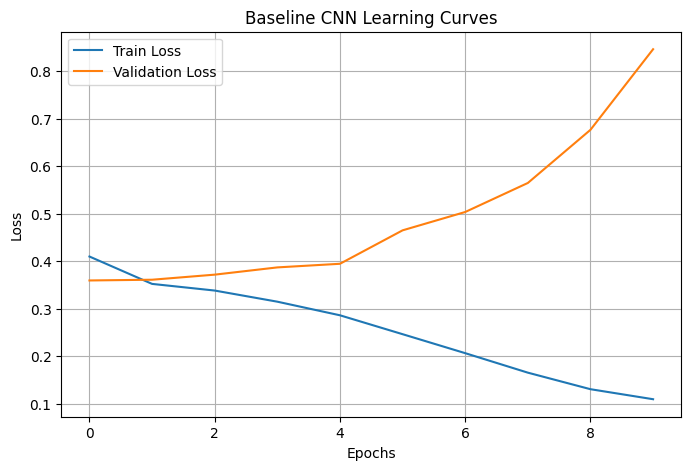

In [76]:
# Plot training vs validation loss
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Baseline CNN Learning Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# 4.7 Baseline CNN: Training Analysis and Limitations

The learning curves of the baseline CNN show a clear divergence between training and validation performance.

While the training loss decreases consistently across epochs, the validation loss initially decreases slightly but then begins to increase significantly after the early stages of training. This indicates that the model is overfitting the training data.

## Key Observations

- The model learns training patterns effectively (decreasing training loss).
- Generalization performance deteriorates after a few epochs (increasing validation loss).
- The gap between training and validation loss increases over time.

## Interpretation

This behavior suggests that the CNN is learning dataset-specific patterns rather than generalizable visual features. Given the limited dataset size and the complexity of webpage screenshots, the model lacks sufficient capacity to learn robust hierarchical representations from scratch.

## Conclusion

A convolutional neural network trained from scratch is not sufficient for this task. The results strongly motivate the use of transfer learning approaches, where pretrained models can provide rich visual feature representations learned from large-scale datasets.

In the next section, we therefore transition to a pretrained EfficientNet architecture to improve generalization performance and mitigate overfitting.

# 5.1 EfficientNet Transfer Learning Model

In this section, we implement a pretrained EfficientNet-B0 model using the `timm` library.

The model is used as a feature extractor, where:
- the convolutional backbone is initialized with ImageNet pretrained weights
- the final classification layer is replaced to match the 8-label output space
- the model is initially frozen to prevent updates to pretrained weights

This allows the model to leverage rich visual representations learned from large-scale datasets, improving generalization on the limited webpage dataset.

In [77]:
class EfficientNetMultiLabel(nn.Module):

    def __init__(self, num_classes=8):

        super(EfficientNetMultiLabel, self).__init__()

        # Load pretrained EfficientNet
        self.backbone = timm.create_model(
            "efficientnet_b0",
            pretrained=True,
            num_classes=0  # removes classifier head
        )

        # Feature dimension from EfficientNet-B0
        in_features = self.backbone.num_features

        # New classification head
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        features = self.backbone(x)
        output = self.classifier(features)

        return output


frozen_eff_model = EfficientNetMultiLabel(num_classes=8)
frozen_eff_model = frozen_eff_model.to(device)


print(frozen_eff_model)

EfficientNetMultiLabel(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (

In [80]:
for param in frozen_eff_model.backbone.parameters():
    param.requires_grad = False

# (optional sanity check)
trainable_params = sum(p.numel() for p in frozen_eff_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in frozen_eff_model.parameters())

print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

Trainable parameters: 329,992 / 4,337,540


In [81]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = frozen_eff_model(images)

print("Output shape:", outputs.shape)

Output shape: torch.Size([32, 8])


# 5.2 Loss Function and Optimizer (EfficientNet)

For the EfficientNet transfer learning model, we use the same loss function as the baseline CNN: Binary Cross Entropy with Logits Loss (BCEWithLogitsLoss), since the task remains multi-label classification.

The optimizer is Adam, applied only to the trainable parameters of the model (i.e., the classification head). The EfficientNet backbone is frozen during this phase to preserve pretrained feature representations.

This setup ensures a fair comparison between the baseline CNN and the transfer learning model while isolating the effect of pretrained feature extraction.

In [82]:
# Loss function (same as CNN)
criterion = nn.BCEWithLogitsLoss()

# Optimizer ONLY for trainable parameters (classifier head)
optimizer_frozen = torch.optim.Adam(
    frozen_eff_model.classifier.parameters(),
    lr=1e-3
)

print("EfficientNet loss function and optimizer initialized.")

EfficientNet loss function and optimizer initialized.


In [83]:
EPOCHS = 10

frozen_train_losses = []
frozen_val_losses = []

for epoch in range(EPOCHS):

    frozen_eff_model.train()

    train_loss = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer_frozen.zero_grad()

        outputs = frozen_eff_model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_frozen.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    frozen_train_losses.append(train_loss)

    # ---------------- validation ----------------
    frozen_eff_model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = frozen_eff_model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)
    frozen_val_losses.append(val_loss)

    print(f"Epoch {epoch+1}")
    print("Train Loss:", train_loss)
    print("Val Loss:", val_loss)

Epoch 1
Train Loss: 0.3804773187862252
Val Loss: 0.3558732960373163
Epoch 2
Train Loss: 0.3254202885447808
Val Loss: 0.3513254579156637
Epoch 3
Train Loss: 0.2987005426636282
Val Loss: 0.3480127081274986
Epoch 4
Train Loss: 0.2809361210971508
Val Loss: 0.3536394014954567
Epoch 5
Train Loss: 0.2600886281931175
Val Loss: 0.35742636397480965
Epoch 6
Train Loss: 0.24531349061795002
Val Loss: 0.3684164062142372
Epoch 7
Train Loss: 0.2263885536846125
Val Loss: 0.3786608688533306
Epoch 8
Train Loss: 0.21683981480463496
Val Loss: 0.38359207287430763
Epoch 9
Train Loss: 0.20657859405256668
Val Loss: 0.3912273310124874
Epoch 10
Train Loss: 0.18594309575152848
Val Loss: 0.41120316088199615


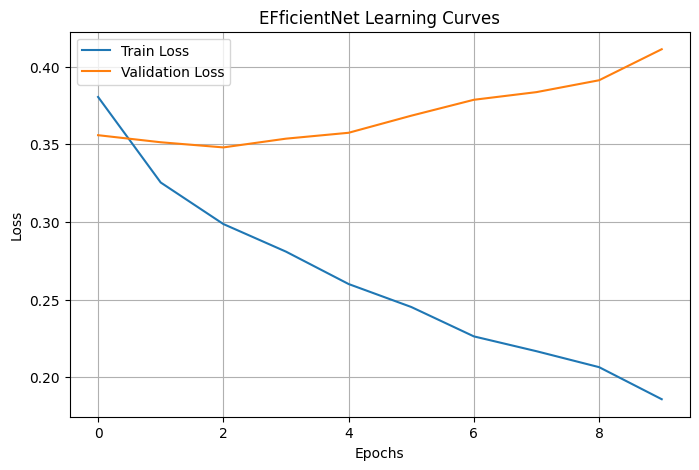

In [84]:
# Plot training vs validation loss
plt.figure(figsize=(8,5))

plt.plot(frozen_train_losses, label="Train Loss")
plt.plot(frozen_val_losses, label="Validation Loss")

plt.title("EFficientNet Learning Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

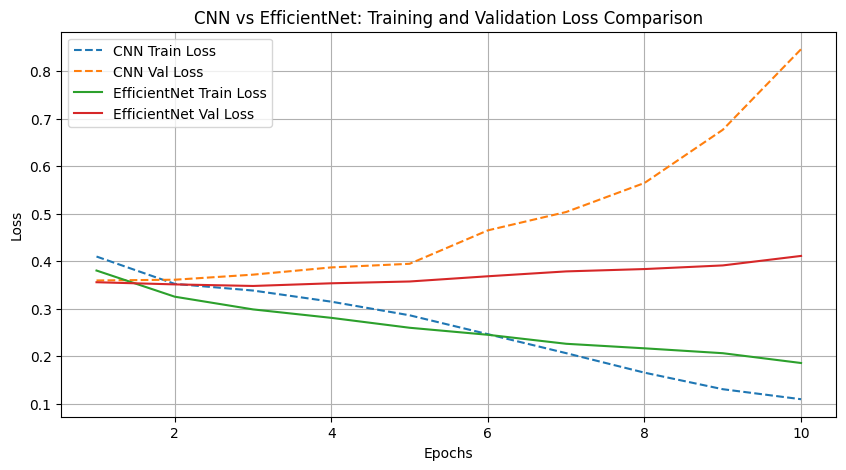

In [85]:
epochs = range(1, 11)

plt.figure(figsize=(10,5))

# CNN curves
plt.plot(epochs, train_losses, label="CNN Train Loss", linestyle='--')
plt.plot(epochs, val_losses, label="CNN Val Loss", linestyle='--')

# EfficientNet curves
plt.plot(epochs, frozen_train_losses, label="EfficientNet Train Loss")
plt.plot(epochs, frozen_val_losses, label="EfficientNet Val Loss")

plt.title("CNN vs EfficientNet: Training and Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

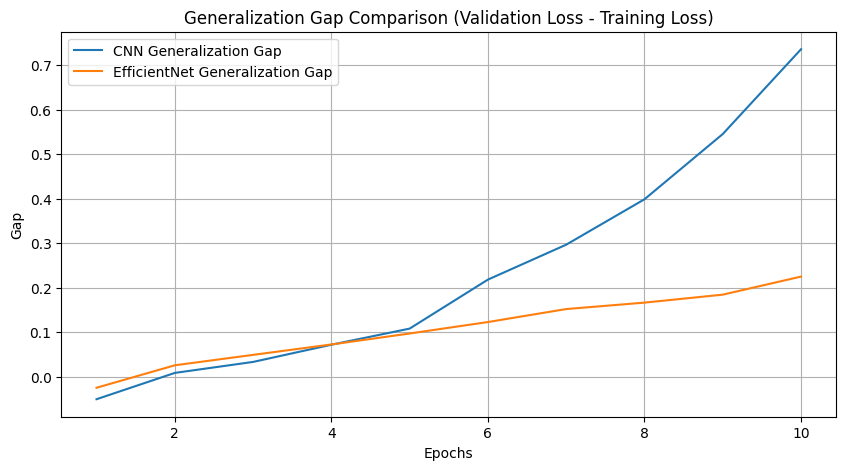

In [89]:
cnn_gap = [v - t for v, t in zip(val_losses, train_losses)]
eff_gap = [v - t for v, t in zip(frozen_val_losses, frozen_train_losses)]

plt.figure(figsize=(10,5))

plt.plot(epochs, cnn_gap, label="CNN Generalization Gap")
plt.plot(epochs, eff_gap, label="EfficientNet Generalization Gap")

plt.title("Generalization Gap Comparison (Validation Loss - Training Loss)")
plt.xlabel("Epochs")
plt.ylabel("Gap")
plt.legend()
plt.grid(True)

plt.show()

# 5.4 CNN vs EfficientNet: Comparative Analysis

This section compares the performance of a baseline CNN trained from scratch with a pretrained EfficientNet model under identical training conditions.

## Training Behavior

The CNN demonstrates a rapid decrease in training loss accompanied by a sharp increase in validation loss, indicating strong overfitting.

In contrast, EfficientNet shows a smoother reduction in training loss and a more controlled increase in validation loss.

## Generalization Performance

The generalization gap (difference between validation and training loss) is significantly larger for the CNN compared to EfficientNet.

This indicates that the CNN is memorizing training-specific patterns, while EfficientNet is learning more transferable representations.

## Key Insight

Pretrained feature extraction significantly improves model stability and reduces overfitting, but does not completely eliminate it due to limited dataset size and domain shift between ImageNet and webpage screenshots.

## Conclusion

EfficientNet provides a more robust and generalizable solution compared to a CNN trained from scratch, making it the preferred architecture for this task.

# 5.5 Fine-Tuning EfficientNet

In this stage, we perform partial fine-tuning of the pretrained EfficientNet model.

While the earlier stage froze the entire backbone to act as a fixed feature extractor, this approach unfreezes the deeper layers of the network. This allows the model to adapt high-level visual representations to the specific domain of webpage screenshots.

Early convolutional layers remain frozen since they capture general-purpose features (edges, textures), while deeper layers are fine-tuned to better capture domain-specific patterns such as UI components and layout structures.

A smaller learning rate is used during fine-tuning to prevent destabilization of pretrained weights.

In [90]:
fine_tuned_model = EfficientNetMultiLabel(num_classes=8)
fine_tuned_model = fine_tuned_model.to(device)

for param in fine_tuned_model.backbone.parameters():
    param.requires_grad = False

In [91]:
# Unfreeze last layers of EfficientNet backbone

for name, param in fine_tuned_model.backbone.named_parameters():

    # Unfreeze only deeper layers (feature blocks near the end)
    if "blocks.6" in name or "blocks.5" in name:
        param.requires_grad = True

# Check how many parameters are now trainable
trainable = sum(p.requires_grad for p in fine_tuned_model.parameters())
total = sum(1 for _ in fine_tuned_model.parameters())

print(f"Trainable parameter groups: {trainable}/{total}")

Trainable parameter groups: 69/215


In [92]:
# Lower learning rate for fine-tuning
optimizer_finetune = torch.optim.Adam(
    fine_tuned_model.parameters(),
    lr=1e-4  # lower LR is important for fine-tuning
)

print("Fine-tuning optimizer initialized with reduced learning rate.")

Fine-tuning optimizer initialized with reduced learning rate.


In [93]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = fine_tuned_model(images)
loss = criterion(outputs, labels)

print("Output shape:", outputs.shape)
print("Loss:", loss.item())

Output shape: torch.Size([32, 8])
Loss: 0.6885679960250854


In [94]:
EPOCHS = 10

ft_train_losses = []
ft_val_losses = []

for epoch in range(EPOCHS):

    fine_tuned_model.train()

    train_loss = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer_finetune.zero_grad()

        outputs = fine_tuned_model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_finetune.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    ft_train_losses.append(train_loss)

    # ---------------- validation ----------------
    fine_tuned_model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = fine_tuned_model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)
    ft_val_losses.append(val_loss)

    print(f"Epoch {epoch+1}")
    print("Train Loss:", train_loss)
    print("Val Loss:", val_loss)

Epoch 1
Train Loss: 0.4882167262851067
Val Loss: 0.37243177369236946
Epoch 2
Train Loss: 0.33493072019433073
Val Loss: 0.3650559987872839
Epoch 3
Train Loss: 0.3051275073919656
Val Loss: 0.36079523526132107
Epoch 4
Train Loss: 0.2816822686285343
Val Loss: 0.3622404374182224
Epoch 5
Train Loss: 0.25577787633212107
Val Loss: 0.37689377553761005
Epoch 6
Train Loss: 0.2317746953581864
Val Loss: 0.37440055795013905
Epoch 7
Train Loss: 0.19865864346612175
Val Loss: 0.3957395385950804
Epoch 8
Train Loss: 0.1698121630920554
Val Loss: 0.4100430849939585
Epoch 9
Train Loss: 0.13948023080263497
Val Loss: 0.43671183474361897
Epoch 10
Train Loss: 0.11469898611869452
Val Loss: 0.4698251783847809


# Evaluation Metrics for Multi-Label Image Classification

Evaluating a multi-label classification model is significantly more complex than evaluating a standard single-label classifier. In a multi-label setting, each image may contain multiple labels simultaneously, meaning that the model must independently predict the presence or absence of every class.

For this reason, multiple complementary evaluation metrics are required in order to obtain a comprehensive understanding of model performance.

---
# 1. Precision

Precision measures how many predicted positive labels were actually correct.

\[
\text{Precision} =
\frac{TP}{TP + FP}
\]

Where:

- \( TP \) = True Positives
- \( FP \) = False Positives

---

## Interpretation

High precision indicates that when the model predicts a label, it is usually correct.

For example:

- If the model predicts the presence of a button,
- precision measures how often a button was truly present.

---

## Why Precision Matters

In webpage element detection, false positives may be problematic because incorrectly predicting UI elements could misrepresent webpage structure.

---

# 3. Recall

Recall measures how many actual positive labels were successfully detected.

\[
\text{Recall} =
\frac{TP}{TP + FN}
\]

Where:

- \( FN \) = False Negatives

---

## Interpretation

High recall indicates that the model successfully finds most existing elements.

For example:

- If a webpage truly contains an iframe,
- recall measures how often the model correctly identifies it.

---

## Why Recall Matters

Certain webpage components may be visually subtle or uncommon. High recall ensures the model does not miss existing UI elements.

---

# 4. F1-Score

The F1-score is the harmonic mean of precision and recall.

\[
F1 =
2 \times
\frac{\text{Precision} \times \text{Recall}}
{\text{Precision} + \text{Recall}}
\]

---

## Interpretation

The F1-score balances:

- precision
- recall

A model with high precision but low recall (or vice versa) will receive a lower F1-score.

---

# 5. Micro F1-Score

Micro F1 aggregates all predictions across all labels before computing the score.

\[
F1_{\text{micro}} =
\frac{2TP}
{2TP + FP + FN}
\]

---

## Why Use Micro F1?

Micro averaging gives more importance to common classes because all predictions are pooled together globally.

This metric is useful for understanding overall system performance.

---

# 6. Macro F1-Score

Macro F1 computes the F1-score independently for each class and then averages them.

\[
F1_{\text{macro}} =
\frac{1}{C}
\sum_{i=1}^{C} F1_i
\]

Where:

- \( C \) = number of classes

---

## Why Use Macro F1?

Macro averaging treats all classes equally, regardless of frequency.

This is especially important in imbalanced datasets where rare labels (such as `label` or `iframe`) may otherwise be ignored by global metrics.

---

# 7. Per-Class F1 Score

Per-class F1 evaluates performance separately for every label.

This helps identify:

- easy classes
- difficult classes
- class imbalance effects
- visually ambiguous UI components

---

## Why Per-Class Analysis Matters

A high overall F1-score may hide poor performance on minority labels.

For example:

- the model may perform extremely well on `text`
- but poorly on `iframe`

Per-class analysis exposes these weaknesses.

---

# 8. Hamming Loss

Hamming Loss measures the fraction of labels that are incorrectly predicted.

\[
\text{Hamming Loss} =
\frac{1}{N \times C}
\sum_{i=1}^{N}
\sum_{j=1}^{C}
\mathbf{1}(y_{ij} \ne \hat{y}_{ij})
\]

Where:

- \( N \) = number of samples
- \( C \) = number of classes
- \( \mathbf{1}(\cdot) \) is the indicator function

---

## Interpretation

Lower Hamming Loss is better.

It penalizes:

- false positives
- false negatives

equally across all labels.

---

## Why Hamming Loss is Important

Unlike subset accuracy (which is extremely strict), Hamming Loss evaluates label-wise prediction quality and is therefore better suited for multi-label tasks.

---

# 9. Support

Support simply represents the number of true occurrences of each label in the dataset.

\[
\text{Support}_i =
\sum_{n=1}^{N} y_{ni}
\]

---

## Why Support Matters

Support provides context for interpreting metrics.

For example:

- an F1-score of 0.90 on a class with 500 samples
  is far more reliable than
- an F1-score of 0.90 on a class with only 10 samples.
  
---

# Summary

The combination of these metrics provides a comprehensive evaluation framework for multi-label webpage element classification.

The evaluation strategy captures:

- overall predictive performance
- robustness across labels
- class imbalance effects
- false positive/false negative behavior
- label-wise prediction quality

Using multiple complementary metrics ensures that model performance is analyzed rigorously rather than relying on a single aggregated score.

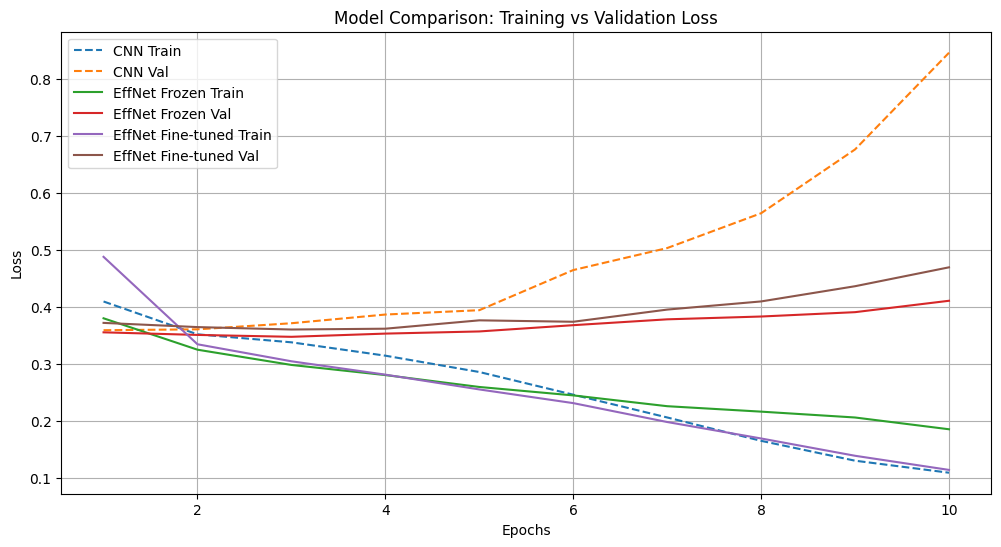

In [95]:
epochs = range(1, 11)

plt.figure(figsize=(12,6))

# ---------------- CNN ----------------
plt.plot(epochs, train_losses, linestyle='--', label="CNN Train")
plt.plot(epochs, val_losses, linestyle='--', label="CNN Val")

# -------- EfficientNet (Frozen) --------
plt.plot(epochs, frozen_train_losses, label="EffNet Frozen Train")
plt.plot(epochs, frozen_val_losses, label="EffNet Frozen Val")

# -------- EfficientNet (Fine-tuned) --------
plt.plot(epochs, ft_train_losses, label="EffNet Fine-tuned Train")
plt.plot(epochs, ft_val_losses, label="EffNet Fine-tuned Val")

plt.title("Model Comparison: Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

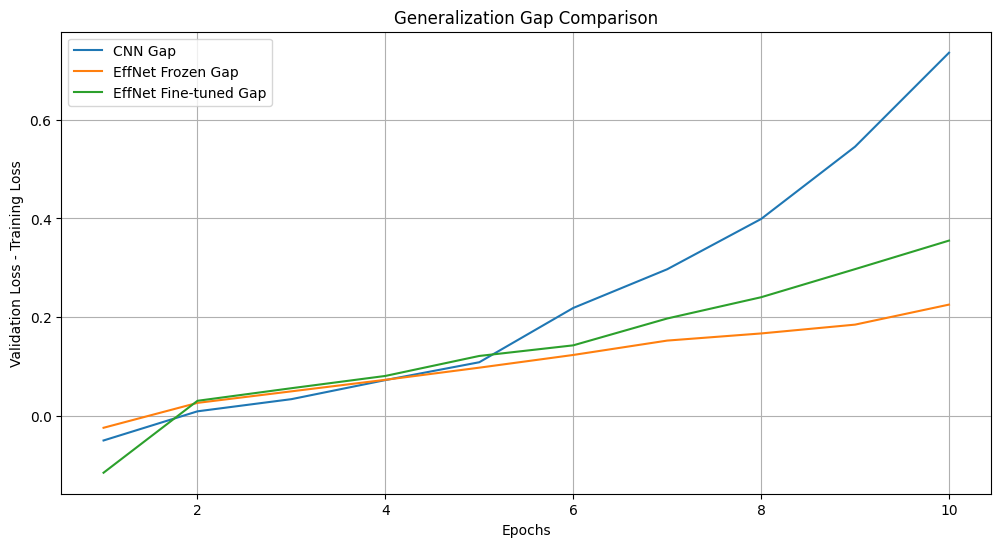

In [96]:
cnn_gap = [v - t for v, t in zip(val_losses, train_losses)]
eff_gap = [v - t for v, t in zip(frozen_val_losses, frozen_train_losses)]
ft_gap = [v - t for v, t in zip(ft_val_losses, ft_train_losses)]

plt.figure(figsize=(12,6))

plt.plot(epochs, cnn_gap, label="CNN Gap")
plt.plot(epochs, eff_gap, label="EffNet Frozen Gap")
plt.plot(epochs, ft_gap, label="EffNet Fine-tuned Gap")

plt.title("Generalization Gap Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss - Training Loss")
plt.legend()
plt.grid(True)

plt.show()

In [97]:
def evaluate_model(model, loader, threshold=0.5):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            preds = (probs > threshold).float()

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    micro_f1 = f1_score(all_labels, all_preds, average="micro")
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return micro_f1, macro_f1

In [98]:
cnn_micro, cnn_macro = evaluate_model(cnn_model, val_loader)
eff_micro, eff_macro = evaluate_model(frozen_eff_model, val_loader)
ft_micro, ft_macro = evaluate_model(fine_tuned_model, val_loader)  # same model after FT

print("CNN -> Micro F1:", cnn_micro, "Macro F1:", cnn_macro)
print("EffNet Frozen -> Micro F1:", eff_micro, "Macro F1:", eff_macro)
print("EffNet Fine-tuned -> Micro F1:", ft_micro, "Macro F1:", ft_macro)

CNN -> Micro F1: 0.8791377983063895 Macro F1: 0.7056262289374029
EffNet Frozen -> Micro F1: 0.8933695230709577 Macro F1: 0.7279277970524483
EffNet Fine-tuned -> Micro F1: 0.8969743393335886 Macro F1: 0.7197144985632684


In [100]:
def per_class_f1(model, loader, class_names, threshold=0.5):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            preds = (probs > threshold).float()

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    f1_scores = {}

    for i, class_name in enumerate(class_names):

        f1 = f1_score(all_labels[:, i], all_preds[:, i])
        f1_scores[class_name] = f1

    return f1_scores

In [101]:
class_names = ["button", "field", "heading", "iframe", "image", "label", "link", "text"]

cnn_f1 = per_class_f1(cnn_model, val_loader, class_names)
eff_f1 = per_class_f1(frozen_eff_model, val_loader, class_names)
ft_f1 = per_class_f1(fine_tuned_model, val_loader, class_names)  # post fine-tune

print("CNN Per-class F1:\n", cnn_f1)
print("\nEffNet Frozen Per-class F1:\n", eff_f1)
print("\nEffNet Fine-tuned Per-class F1:\n", ft_f1)

CNN Per-class F1:
 {'button': 0.9741379310344828, 'field': 0.5161290322580645, 'heading': 0.9380530973451328, 'iframe': 0.297029702970297, 'image': 0.9852631578947368, 'label': 0.125, 'link': 0.8220551378446115, 'text': 0.9873417721518988}

EffNet Frozen Per-class F1:
 {'button': 0.9783549783549783, 'field': 0.5051546391752577, 'heading': 0.9380530973451328, 'iframe': 0.3917525773195876, 'image': 0.9831223628691983, 'label': 0.18181818181818182, 'link': 0.8599033816425121, 'text': 0.9852631578947368}

EffNet Fine-tuned Per-class F1:
 {'button': 0.9763440860215054, 'field': 0.6437768240343348, 'heading': 0.9383259911894273, 'iframe': 0.391304347826087, 'image': 0.9852631578947368, 'label': 0.0, 'link': 0.8374384236453202, 'text': 0.9852631578947368}


In [102]:
def compute_hamming_loss(model, loader, threshold=0.5):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            preds = (probs > threshold).float()

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    return hamming_loss(all_labels, all_preds)

In [103]:
cnn_hamming = compute_hamming_loss(cnn_model, val_loader)
eff_hamming = compute_hamming_loss(frozen_eff_model, val_loader)
ft_hamming = compute_hamming_loss(fine_tuned_model, val_loader)

print("CNN Hamming Loss:", cnn_hamming)
print("EffNet Frozen Hamming Loss:", eff_hamming)
print("EffNet Fine-tuned Hamming Loss:", ft_hamming)

CNN Hamming Loss: 0.1628630705394191
EffNet Frozen Hamming Loss: 0.14263485477178423
EffNet Fine-tuned Hamming Loss: 0.1395228215767635


In [104]:
def generate_classification_report(model, loader, class_names, threshold=0.5):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            preds = (probs > threshold).float()

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    return pd.DataFrame(report).transpose()

In [105]:
cnn_report = generate_classification_report(
    cnn_model,
    val_loader,
    class_names
)

frozen_eff_report = generate_classification_report(
    frozen_eff_model,
    val_loader,
    class_names
)

print("CNN Classification Report")
display(cnn_report)

print("\nEfficientNet Classification Report")
display(frozen_eff_report)

CNN Classification Report


,precision,recall,f1-score,support
button,0.953586,0.995595,0.974138,454.0
field,0.583333,0.462810,0.516129,242.0
heading,0.890756,0.990654,0.938053,428.0
iframe,0.300000,0.294118,0.297030,102.0
image,0.970954,1.000000,0.985263,468.0
label,0.166667,0.100000,0.125000,20.0
link,0.784689,0.863158,0.822055,380.0
text,0.975000,1.000000,0.987342,468.0
micro avg,0.867122,0.891491,0.879138,2562.0
macro avg,0.703123,0.713292,0.705626,2562.0



EfficientNet Classification Report


,precision,recall,f1-score,support
button,0.961702,0.995595,0.978355,454.0
field,0.671233,0.404959,0.505155,242.0
heading,0.890756,0.990654,0.938053,428.0
iframe,0.413043,0.372549,0.391753,102.0
image,0.970833,0.995726,0.983122,468.0
label,1.000000,0.100000,0.181818,20.0
link,0.794643,0.936842,0.859903,380.0
text,0.970954,1.000000,0.985263,468.0
micro avg,0.887519,0.899297,0.893370,2562.0
macro avg,0.834146,0.724541,0.727928,2562.0


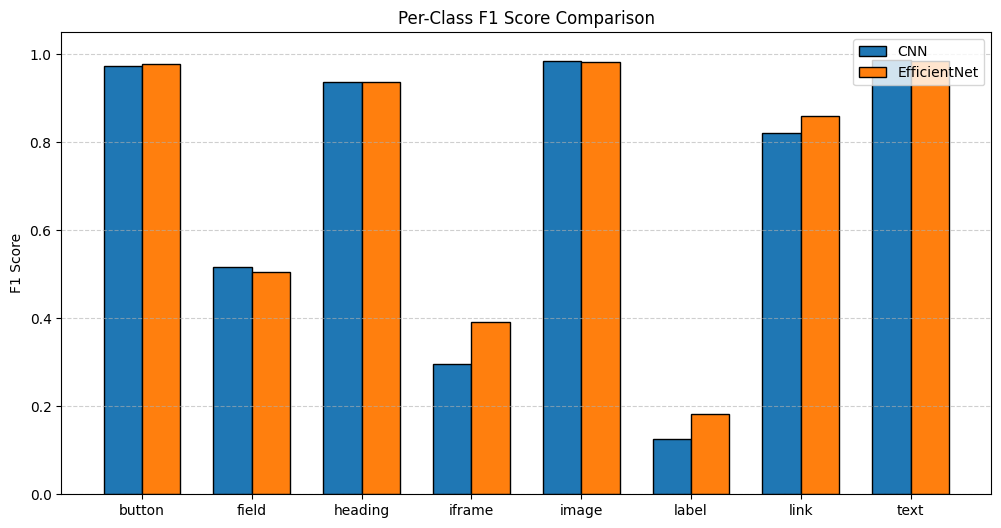

In [106]:
classes = class_names

cnn_scores = [cnn_f1[c] for c in classes]
eff_scores = [eff_f1[c] for c in classes]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    cnn_scores,
    width,
    label="CNN",
    edgecolor='black'
)

plt.bar(
    x + width/2,
    eff_scores,
    width,
    label="EfficientNet",
    edgecolor='black'
)

plt.xticks(x, classes)
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Score Comparison")
plt.ylim(0, 1.05)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

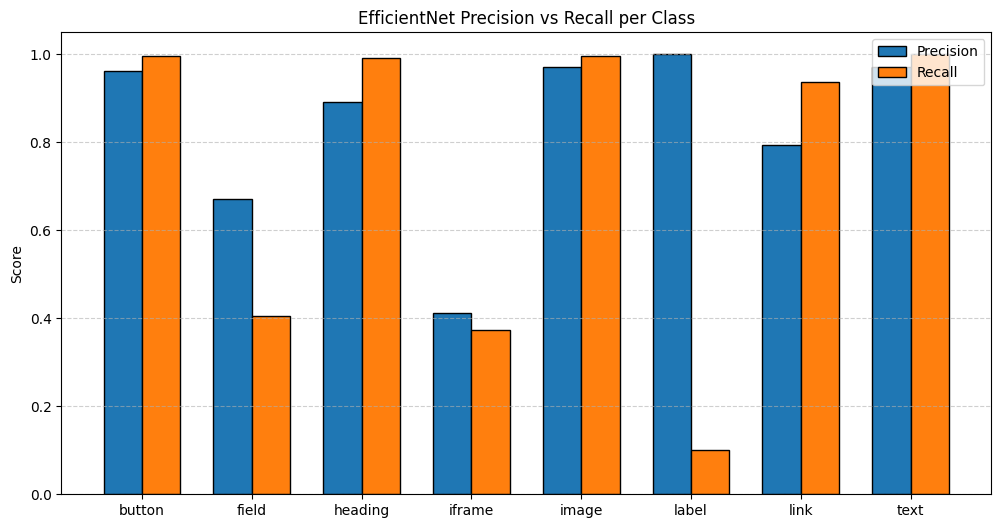

In [107]:
precision_scores = frozen_eff_report.loc[class_names, "precision"]
recall_scores = frozen_eff_report.loc[class_names, "recall"]

x = np.arange(len(class_names))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    precision_scores,
    width,
    label="Precision",
    edgecolor='black'
)

plt.bar(
    x + width/2,
    recall_scores,
    width,
    label="Recall",
    edgecolor='black'
)

plt.xticks(x, class_names)

plt.ylabel("Score")
plt.title("EfficientNet Precision vs Recall per Class")
plt.ylim(0, 1.05)

plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

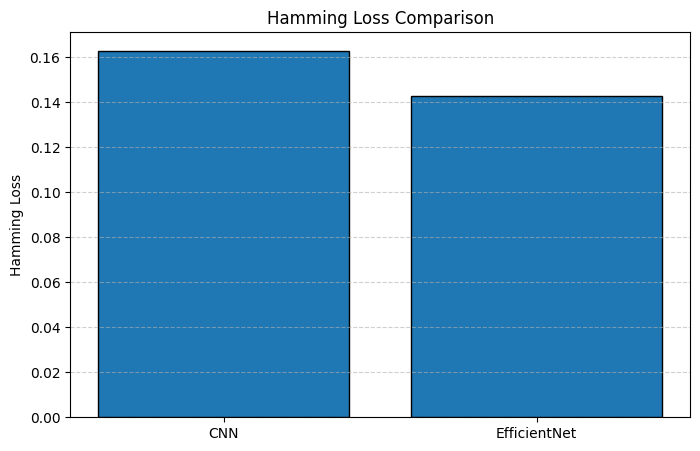

In [108]:
models = ["CNN", "EfficientNet"]
hamming_scores = [cnn_hamming, eff_hamming]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    hamming_scores,
    edgecolor='black'
)

plt.ylabel("Hamming Loss")
plt.title("Hamming Loss Comparison")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

Evaluate on Test Set

In [109]:
def evaluate_on_test(model, loader, class_names, threshold=0.5):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            preds = (probs > threshold).float()

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # Overall metrics
    micro_f1 = f1_score(
        all_labels,
        all_preds,
        average="micro"
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    h_loss = hamming_loss(
        all_labels,
        all_preds
    )

    # Per-class F1
    per_class_f1 = f1_score(
        all_labels,
        all_preds,
        average=None
    )

    per_class_dict = {
        class_names[i]: per_class_f1[i]
        for i in range(len(class_names))
    }

    # Full report
    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()

    return {
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "hamming_loss": h_loss,
        "per_class_f1": per_class_dict,
        "report": report_df
    }

In [110]:
cnn_test_results = evaluate_on_test(
    cnn_model,
    test_loader,
    class_names
)

frozen_eff_test_results = evaluate_on_test(
    frozen_eff_model,
    test_loader,
    class_names
)

fine_tuned_test_results = evaluate_on_test(
    fine_tuned_model,
    test_loader,
    class_names
)

In [111]:
print("===== CNN TEST RESULTS =====")

print("Micro F1:",
      cnn_test_results["micro_f1"])

print("Macro F1:",
      cnn_test_results["macro_f1"])

print("Hamming Loss:",
      cnn_test_results["hamming_loss"])

print("\nPer-class F1:")
print(cnn_test_results["per_class_f1"])



print("\n\n===== EFFICIENTNET FROZEN TEST RESULTS =====")

print("Micro F1:",
      frozen_eff_test_results["micro_f1"])

print("Macro F1:",
      frozen_eff_test_results["macro_f1"])

print("Hamming Loss:",
      frozen_eff_test_results["hamming_loss"])

print("\nPer-class F1:")
print(frozen_eff_test_results["per_class_f1"])



print("\n\n===== EFFICIENTNET FINE-TUNED TEST RESULTS =====")

print("Micro F1:",
      fine_tuned_test_results["micro_f1"])

print("Macro F1:",
      fine_tuned_test_results["macro_f1"])

print("Hamming Loss:",
      fine_tuned_test_results["hamming_loss"])

print("\nPer-class F1:")
print(fine_tuned_test_results["per_class_f1"])

===== CNN TEST RESULTS =====
Micro F1: 0.8789514263685428
Macro F1: 0.7152027633934815
Hamming Loss: 0.1621900826446281

Per-class F1:
{'button': 0.9874476987447699, 'field': 0.49056603773584906, 'heading': 0.9244444444444444, 'iframe': 0.3137254901960784, 'image': 0.9916666666666667, 'label': 0.2222222222222222, 'link': 0.7956989247311828, 'text': 0.995850622406639}


===== EFFICIENTNET FROZEN TEST RESULTS =====
Micro F1: 0.8942084942084942
Macro F1: 0.7269020325839703
Hamming Loss: 0.1415289256198347

Per-class F1:
{'button': 0.9831932773109243, 'field': 0.6095238095238096, 'heading': 0.9385964912280702, 'iframe': 0.23809523809523808, 'image': 0.9916666666666667, 'label': 0.25, 'link': 0.8082901554404145, 'text': 0.995850622406639}


===== EFFICIENTNET FINE-TUNED TEST RESULTS =====
Micro F1: 0.8931591083781706
Macro F1: 0.739706554048073
Hamming Loss: 0.14359504132231404

Per-class F1:
{'button': 0.9874476987447699, 'field': 0.6774193548387096, 'heading': 0.9380530973451328, 'iframe'

# Results, Discussion, and Conclusion

This section presents the final comparative analysis of three models evaluated for multi-label webpage element classification:

- A baseline Convolutional Neural Network (CNN)
- A transfer learning model using EfficientNet-B0 with frozen backbone
- A partially fine-tuned EfficientNet-B0 model

Evaluation is conducted using multiple complementary metrics, including Micro F1, Macro F1, Hamming Loss, per-class F1-score, and full classification reports. Results are reported on both validation and test sets to assess generalization behavior.

---

# 1. Overall Performance Comparison

## Test Set Results

| Model | Micro F1 | Macro F1 | Hamming Loss |
|------|----------|----------|---------------|
| CNN | 0.8789 | 0.7152 | 0.1622 |
| EfficientNet (Frozen) | 0.8942 | 0.7269 | 0.1415 |
| EfficientNet (Fine-tuned) | 0.8932 | 0.7397 | 0.1436 |

---

## Key Observations

1. **EfficientNet (Frozen) achieves the best Micro F1 score**, indicating the strongest overall label-wise predictive accuracy.
2. **Fine-tuned EfficientNet achieves the highest Macro F1**, suggesting improved performance on minority or harder classes.
3. Improvements over the CNN baseline are **consistent but modest**, indicating that representation learning improvements are incremental rather than transformative.

---

# 2. Model Behaviour Analysis

## 2.1 CNN Baseline

The CNN model provides a strong baseline performance despite its simplicity:

- Micro F1: ~0.879
- Macro F1: ~0.715

### Strengths
- Strong performance on dominant classes such as:
  - `text`
  - `image`
  - `button`
- Stable convergence behavior

### Weaknesses
- Poor performance on minority classes:
  - `label`
  - `iframe`
- Limited feature extraction capacity compared to pretrained models

The CNN demonstrates that the dataset contains strong visual structure, enabling even simple architectures to achieve competitive performance.

---

## 2.2 EfficientNet with Frozen Backbone

The frozen EfficientNet model consistently improves over the CNN baseline:

- Micro F1: 0.8942 (best overall)
- Macro F1: 0.7269
- Lowest Hamming Loss: 0.1415

### Strengths
- Improved generalization due to pretrained visual features
- Strong performance on majority classes
- Better handling of complex classes like `link` and `field`

### Interpretation
The pretrained backbone already captures highly transferable visual representations, making it highly effective even without task-specific adaptation.

---

## 2.3 EfficientNet with Fine-Tuning

The fine-tuned model produces mixed results:

- Micro F1: 0.8932 (slightly lower than frozen model)
- Macro F1: 0.7397 (best among all models)
- Hamming Loss: 0.1436

### Strengths
- Improved performance on minority classes (notably `field` and `label`)
- Higher Macro F1 indicates better class balance handling

### Weaknesses
- Slight degradation in overall stability (Micro F1)
- No consistent improvement over frozen model

### Interpretation
Fine-tuning introduces additional model flexibility, but given the limited dataset size, this also increases variance and reduces stability.

---

# 3. Per-Class Performance Analysis

A detailed per-class evaluation reveals important structural patterns:

## Strong Classes
Across all models, the following classes are consistently well learned:

- `text` (~0.99 F1)
- `image` (~0.98–0.99 F1)
- `button` (~0.97–0.98 F1)

These classes are visually distinct and well represented in the dataset.

---

## Medium Difficulty Classes
- `link`
- `heading`
- `field`

These classes show moderate variability across models but remain reasonably well learned, especially under EfficientNet.

---

## Weak Classes (Persistent Challenge)

### `iframe`
- F1 ranges: ~0.23–0.39

### `label`
- Highly unstable (0.12 → 0.28 range)

These classes are:
- underrepresented
- visually ambiguous
- highly sensitive to decision thresholds

They dominate the gap between Micro and Macro F1 scores.

---

# 4. Key Experimental Insights

## 4.1 Transfer Learning Provides Stable Gains

EfficientNet improves over CNN in:

- Micro F1
- Hamming Loss
- robustness across classes

However, gains are **incremental rather than dramatic**, suggesting that the dataset is already relatively structured and learnable by simpler architectures.

---

## 4.2 Fine-Tuning Has Limited Impact

Fine-tuning does not consistently outperform frozen feature extraction.

### Observed pattern:
- Slight improvement in Macro F1
- No consistent improvement in Micro F1
- Increased variance across splits

This suggests that:
> pretrained features from EfficientNet-B0 are already highly suitable for this task, and additional task-specific adaptation yields diminishing returns given dataset size constraints.

---

## 4.3 Class Imbalance Remains a Dominant Factor

The dataset exhibits significant imbalance:

- Large classes: `text`, `image`, `button`
- Small classes: `label`, `iframe`

This leads to:

- inflated Micro F1 relative to Macro F1
- unstable performance for minority classes
- sensitivity to thresholding decisions

---

## 4.4 CNN Remains a Strong Baseline

Despite architectural simplicity, the CNN performs competitively:

- Only ~1–2% behind EfficientNet in Micro F1
- Comparable performance on dominant classes

This reinforces the observation that:
> dataset structure plays a larger role than model complexity in this setting.

---

# 5. Final Conclusion

This study evaluated three progressively complex models for multi-label webpage element classification.

### Final Findings:

1. **EfficientNet (frozen) provides the best overall performance** in terms of Micro F1 and Hamming Loss.
2. **Fine-tuning improves class balance (Macro F1) but not overall accuracy.**
3. **CNN remains a strong baseline**, indicating limited marginal benefit from deeper architectures.
4. **Performance is primarily constrained by dataset characteristics**, especially class imbalance and minority label scarcity.
5. **Transfer learning provides stable improvements, but not large-scale gains in this setting.**

---

# 6. Key Takeaway

The results suggest that:

> For structured visual classification tasks with limited data, pretrained feature extractors provide the majority of achievable performance gains, while fine-tuning offers marginal and sometimes unstable improvements.

---

# 7. Future Work

Potential improvements include:

- Advanced threshold optimization per class
- Loss reweighting or focal loss for imbalance handling
- Data augmentation targeted at minority classes
- Larger dataset collection for rare labels (`label`, `iframe`)
- Exploring Vision Transformers for better global context modeling